# Laboratory 5 instruction part 2 - MLflow

In machine learning development, one of the most challenging aspects is maintaining reproducibility. This issue is particularly relevant to the experimental phase, when a lot of small, but influential code changes are constantly introduced.

After extensive experimentation with different model architectures, hyperparameters, and preprocessing techniques, researchers often find themselves unable to recreate their best-performing models because critical configuration details were not properly recorded.

## MLflow

[MLflow is an open-source platform](https://mlflow.org/) that addresses this challenge by providing systematic experiment tracking throughout the machine learning lifecycle. It automatically captures configurations, metrics, and artifacts from each model training run, transforming ad-hoc model development into a structured, reproducible process. In this notebook, we will learn how to use MLflow to properly track experiments for both traditional machine learning and deep learning workflows.


### Laboratory plan

1. **MLflow tracking server** configuration and deployment for experiment management
2. **Automatic logging mechanisms** for scikit-learn experiments
3. **Manual logging implementation** for PyTorch deep learning workflows
4. **Hyperparameter optimization exercise** - systematic hyperparameter exploration
5. **Best practices** for experiment organization, versioning, and cross-team reproducibility


## 1. MLflow Tracking server configuration

[MLflow Tracking](https://mlflow.org/docs/latest/tracking/) is the main component of MLflow, responsible for capturing, storing, and presenting metrics, logs, and other tracking data. MLflow is based on a client-server architecture, where the central MLflow server can serve potentially whole teams of data scientists. You can also simply run it as a local server from the commandline, as we will now.

You have two options for running MLflow:

#### Option 1: Local MLflow (Simple)
1. Open terminal - we recommend to split it into 2 shells or just open additional session.

1. Create a directory for MLflow artifacts storage:
```bash
mkdir mlflow-artifacts
```

2. Start the MLflow tracking server:
```bash
mlflow server \
  --backend-store-uri sqlite:///mlflow.db \
  --default-artifact-root ./mlflow-artifacts \
  --host 0.0.0.0 \
  --port 5001
```


**Important: Keep this terminal window open.** The MLflow server will continue running and be accessible at http://localhost:5001

#### Option 2: MLflow with Docker (Recommended for production-like setup)

1. Create a `docker-compose.yml` file:
```yaml
services:
  mlflow:
    image: ghcr.io/mlflow/mlflow:v2.9.2
    container_name: mlflow-server
    ports:
      - "5001:5000"
    volumes:
      - ./mlflow-data:/mlflow
    command:
      - mlflow
      - server
      - --backend-store-uri
      - sqlite:////mlflow/mlflow.db
      - --default-artifact-root
      - /mlflow/artifacts
      - --host
      - 0.0.0.0
      - --port
      - "5000"
    restart: unless-stopped
```

2. Start MLflow with Docker:
```bash
docker compose down -v
rm -rf mlflow-data
mkdir -p mlflow-data/artifacts
docker compose up -d
```

3. Check if it's running:
```bash
docker-compose ps
```

4. View logs (optional):
```bash
docker-compose logs -f mlflow
```

5. To stop the server later:
```bash
docker-compose down
```

**Important: Add MLflow files to .gitignore**

MLflow creates local files that should not be committed to Git. Add these lines to your `.gitignore`:

```
# MLflow
mlflow.db
mlflow-artifacts/
mlruns/
```

These files contain experiment data and artifacts that are specific to your local machine. In production, you would use a remote tracking server and artifact storage (like S3).

### Connecting to MLflow

To verify if the server runs properly, let's connect to it:

```python
import mlflow
import mlflow.sklearn

import warnings

warnings.filterwarnings("ignore")

mlflow.set_tracking_uri("http://localhost:5001")
print(f"Connected to MLflow at: {mlflow.get_tracking_uri()}")
```

**To stop the MLflow server later:**

- **Local setup**: Press `Ctrl+C` in the terminal where it's running
- **Docker setup**: Run `docker-compose down`

The server will shut down gracefully and save all your experiments.

**Note:** Keep the server running throughout this lab session. All your experiments will be logged to this server instance.


>>> import mlflow
>>> import mlflow.sklearn
>>> import warnings
>>> warnings.filterwarnings("ignore")
>>>
>>> mlflow.set_tracking_uri("http://localhost:5001")
>>> print(f"Connected to MLflow at: {mlflow.get_tracking_uri()}")
Connected to MLflow at: http://localhost:5001

In [1]:
import mlflow
import mlflow.sklearn

import warnings

from sklearn.isotonic import IsotonicRegression
from sklearn.naive_bayes import GaussianNB

warnings.filterwarnings("ignore")

mlflow.set_tracking_uri("http://localhost:5001")
print(f"Connected to MLflow at: {mlflow.get_tracking_uri()}")

Connected to MLflow at: http://localhost:5001


## 2. Automatic logging with scikit-learn

### 2.1 Dataset preparation

In this section, we'll use the Ames Housing dataset to demonstrate MLflow's autologging capabilities with scikit-learn. Since we have already prepared the 2006-2008 data using DVC, we can use our preprocessed dataset here. 

In [2]:
import numpy as np
import pandas as pd

from feature_engine.encoding import RareLabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

In [3]:
df = pd.read_parquet("data/ames_data_2006_2008.parquet")

df = df.sort_values(by=["YrSold"])

# As we have temporal data, the best way to evaluate our model is time (chronological) 
# split, where the newest data is used for testing. We will assume that we have the 
# data #for years 2006 and 2007, and evaluate using data from 2008.

df_train = df[df["YrSold"] < 2008]
df_test = df[df["YrSold"] == 2008]

y_train = df_train.pop("SalePrice")
y_test = df_test.pop("SalePrice")

categorical_features = df_train.select_dtypes(include="object").columns
numerical_features = df_train.select_dtypes(exclude="object").columns

In [4]:
median_imputer = SimpleImputer(strategy="median")
min_max_scaler = MinMaxScaler()
rare_encoder = RareLabelEncoder(tol=0.01, n_categories=0, missing_values='ignore')
one_hot_encoder = OneHotEncoder(
    drop="first", sparse_output=False, handle_unknown="ignore"
)

num_pipeline = Pipeline(
    [("median_imputer", median_imputer), ("min_max_scaler", min_max_scaler)]
)

cat_pipeline = Pipeline(
    [("rare_encoder", rare_encoder), ("one_hot_encoder", one_hot_encoder)]
)

column_transformer = ColumnTransformer(
    [
        ("num_pipeline", num_pipeline, numerical_features),
        ("cat_pipeline", cat_pipeline, categorical_features),
    ],
    verbose_feature_names_out=False,
)
column_transformer.fit(df_train)

X_train = column_transformer.transform(df_train)
X_test = column_transformer.transform(df_test)

In [5]:
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")

Training samples: 1312
Test samples: 621
Number of features: 181


### 2.2 Training with MLflow autologging

Autologging is a powerful built-in capability of MLflow, enabling fully automated and near-zero code integration of MLflow with many popular frameworks. In particular, it works really well with scikit-learn, thanks to its highly unified API. Let's try this out - we will enable autologging, and then train a bunch of different models.

In [6]:
mlflow.sklearn.autolog(
    log_input_examples=True, log_model_signatures=True, log_models=False, silent=False
)

mlflow.set_experiment("ames-housing-autolog")

2026/04/09 01:03:40 WARNING mlflow.utils.autologging_utils: MLflow sklearn autologging is known to be compatible with 0.24.1 <= scikit-learn <= 1.6.1, but the installed version is 1.7.0. If you encounter errors during autologging, try upgrading / downgrading scikit-learn to a compatible version, or try upgrading MLflow.


<Experiment: artifact_location='/Users/bartoszkordek/PycharmProjects/MLOps_course_lab5/mlflow-artifacts/1', creation_time=1775688422413, experiment_id='1', last_update_time=1775688422413, lifecycle_stage='active', name='ames-housing-autolog', tags={}>

In [7]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, MultiTaskLasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

models = [
    ("Ridge Regression", Ridge()),
    ("Decision Tree", DecisionTreeRegressor(max_depth=10, random_state=42)),
    ("K-Nearest Neighbors", KNeighborsRegressor(n_neighbors=10)),
    ("Random Forest", RandomForestRegressor(n_estimators=100, random_state=42)),
    ("Gradient Boosting", GradientBoostingRegressor(n_estimators=100, random_state=42)),
]

In [8]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

def fit_sklearn_models_with_cv(models, X_train, X_test, y_train, y_test):
    results = {}

    for model_name, model in models:

        # start MLflow run - a unit grouping logs from different model runs
        # everything within this context manager will get logged as a run
        with mlflow.start_run(run_name=model_name):
            mlflow.log_param("dvc_data_md5", dvc_metadata.get("md5"))

            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)

            rmse = root_mean_squared_error(y_test, y_pred)
            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)

            cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
            cv_mean = cv_scores.mean()
            cv_std = cv_scores.std()
            
            # log additional custom metrics, in addition to autologging
            mlflow.log_metric("cv_r2_mean", cv_mean)
            mlflow.log_metric("cv_r2_std", cv_std)

            results[model_name] = {
                "rmse": rmse,
                "mae": mae,
                "r2": r2,
                "cv_r2_mean": cv_mean,
            }

            print(f"\n{model_name}:")
            print(f"  RMSE: {rmse:.2f}")
            print(f"  MAE: {mae:.2f}")
            print(f"  R^2: {r2:.3f}")
            print(f"  CV R^2 (mean ± std): {cv_mean:.3f} ± {cv_std:.3f}")

In [10]:
fit_sklearn_models_with_cv(models, X_train, X_test, y_train, y_test)

2026/04/09 00:56:11 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 00:56:11 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 00:56:12 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 00:56:12 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 00:56:12 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 00:56:12 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 00:56:12 WARNING mlflow.sklearn: Failed t


Ridge Regression:
  RMSE: 23450.39
  MAE: 16430.79
  R^2: 0.904
  CV R^2 (mean ± std): 0.895 ± 0.035
🏃 View run Ridge Regression at: http://localhost:5001/#/experiments/1/runs/6d731d445e8144c3a5a4fc6d78e22661
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/04/09 00:56:12 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 00:56:12 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 00:56:12 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 00:56:12 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 00:56:12 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Decision Tree:
  RMSE: 36860.51
  MAE: 23270.66
  R^2: 0.762
  CV R^2 (mean ± std): 0.755 ± 0.057
🏃 View run Decision Tree at: http://localhost:5001/#/experiments/1/runs/a27333f4dbd14950b817d5b30d5c286a
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/04/09 00:56:13 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 00:56:13 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 00:56:13 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 00:56:13 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 00:56:13 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 00:56:13 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



K-Nearest Neighbors:
  RMSE: 38324.60
  MAE: 26033.27
  R^2: 0.743
  CV R^2 (mean ± std): 0.691 ± 0.049
🏃 View run K-Nearest Neighbors at: http://localhost:5001/#/experiments/1/runs/029d363aa9b74befb6b80df89123c2af
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/04/09 00:56:14 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 00:56:16 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 00:56:17 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 00:56:18 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 00:56:19 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 00:56:20 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Random Forest:
  RMSE: 25814.13
  MAE: 15606.16
  R^2: 0.883
  CV R^2 (mean ± std): 0.879 ± 0.049
🏃 View run Random Forest at: http://localhost:5001/#/experiments/1/runs/dfe2a885d779474c8b13e571e48c1cc8
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/04/09 00:56:21 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 00:56:21 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 00:56:22 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 00:56:22 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 00:56:22 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Gradient Boosting:
  RMSE: 21600.50
  MAE: 13840.01
  R^2: 0.918
  CV R^2 (mean ± std): 0.904 ± 0.031
🏃 View run Gradient Boosting at: http://localhost:5001/#/experiments/1/runs/28e358a7b4d84eb1801a5b7f4b471581
🧪 View experiment at: http://localhost:5001/#/experiments/1


Open the MLflow dashboard at http://localhost:5001/ and go to the Experiments tab. On the left, you have the experiment name, and when you select it, the list of all experiments will show up. Click through the interface and familiarize yourself with the most important elements:

1. What columns can be selected
2. Pick a particular run and check what values are logged automatically
3. Select columns to compare a given metric between runs, e.g. MAE
4. Sort algorithms by the selected metric to pick the best one

### 1. Selected columns

![2.1. Selected_columns.png](screenshots/2.1.%20Selected_columns.png)
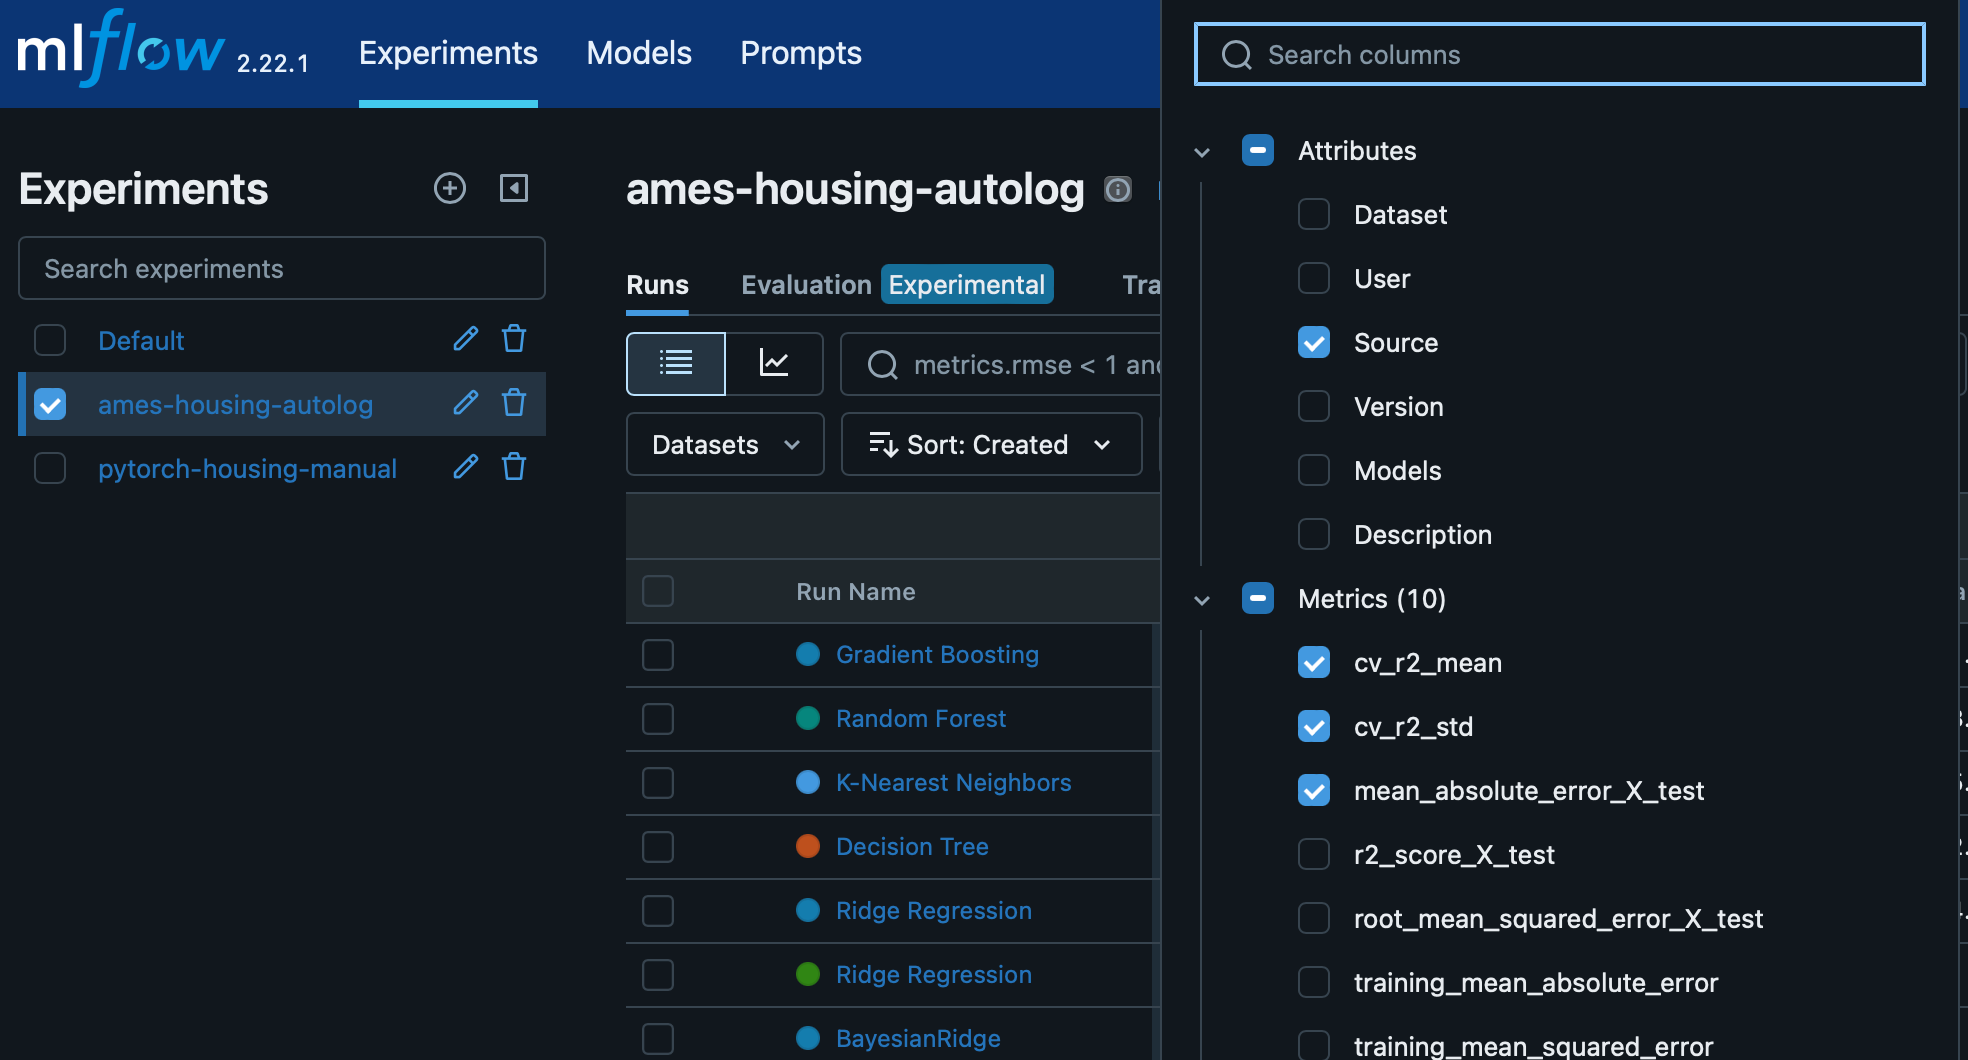

### 2. Pick a particular run and check what values are logged automatically

![2.2. Logged_values_1.png](screenshots/2.2.%20Logged_values_1.png)

![2.2. Logged_values_2.png](screenshots/2.2.%20Logged_values_2.png)

### 3. Select columns to compare a given metric between runs, e.g. MAE


![2.3. columns to compare a given metric_1.png](screenshots/2.3.%20columns%20to%20compare%20a%20given%20metric_1.png)

![2.3. columns to compare a given metric_2.png](screenshots/2.3.%20columns%20to%20compare%20a%20given%20metric_2.png)

### 4. Sort algorithms by the selected metric to pick the best one

The lowest MAE
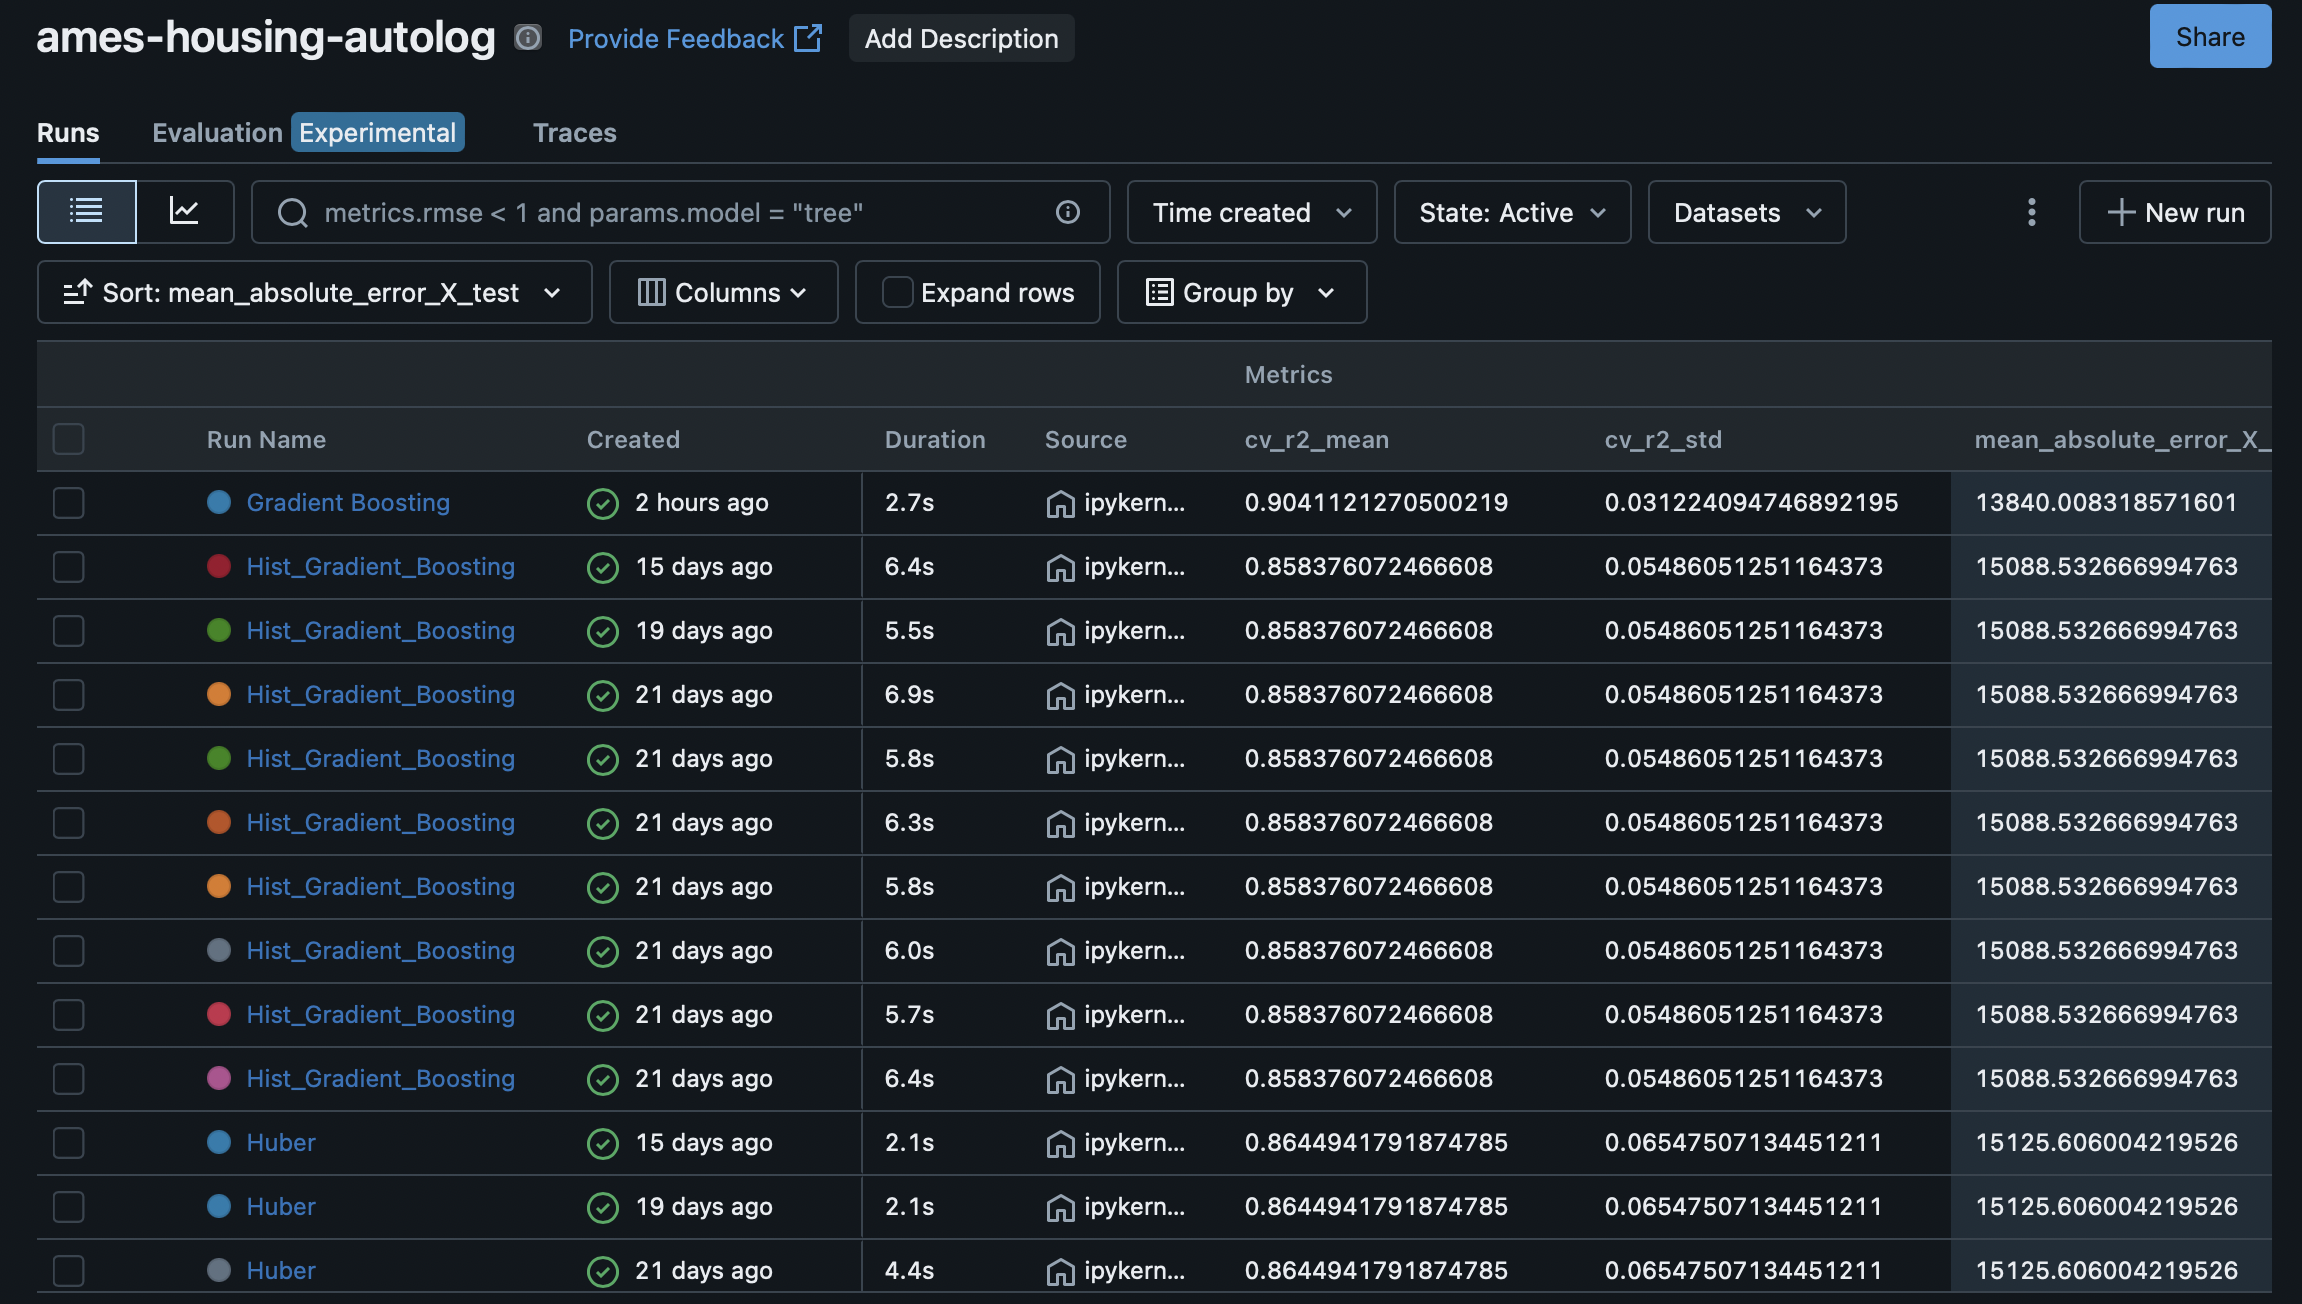

![2.4. The lowest MAE sorted.png](screenshots/2.4.%20The%20lowest%20MAE%20sorted.png)
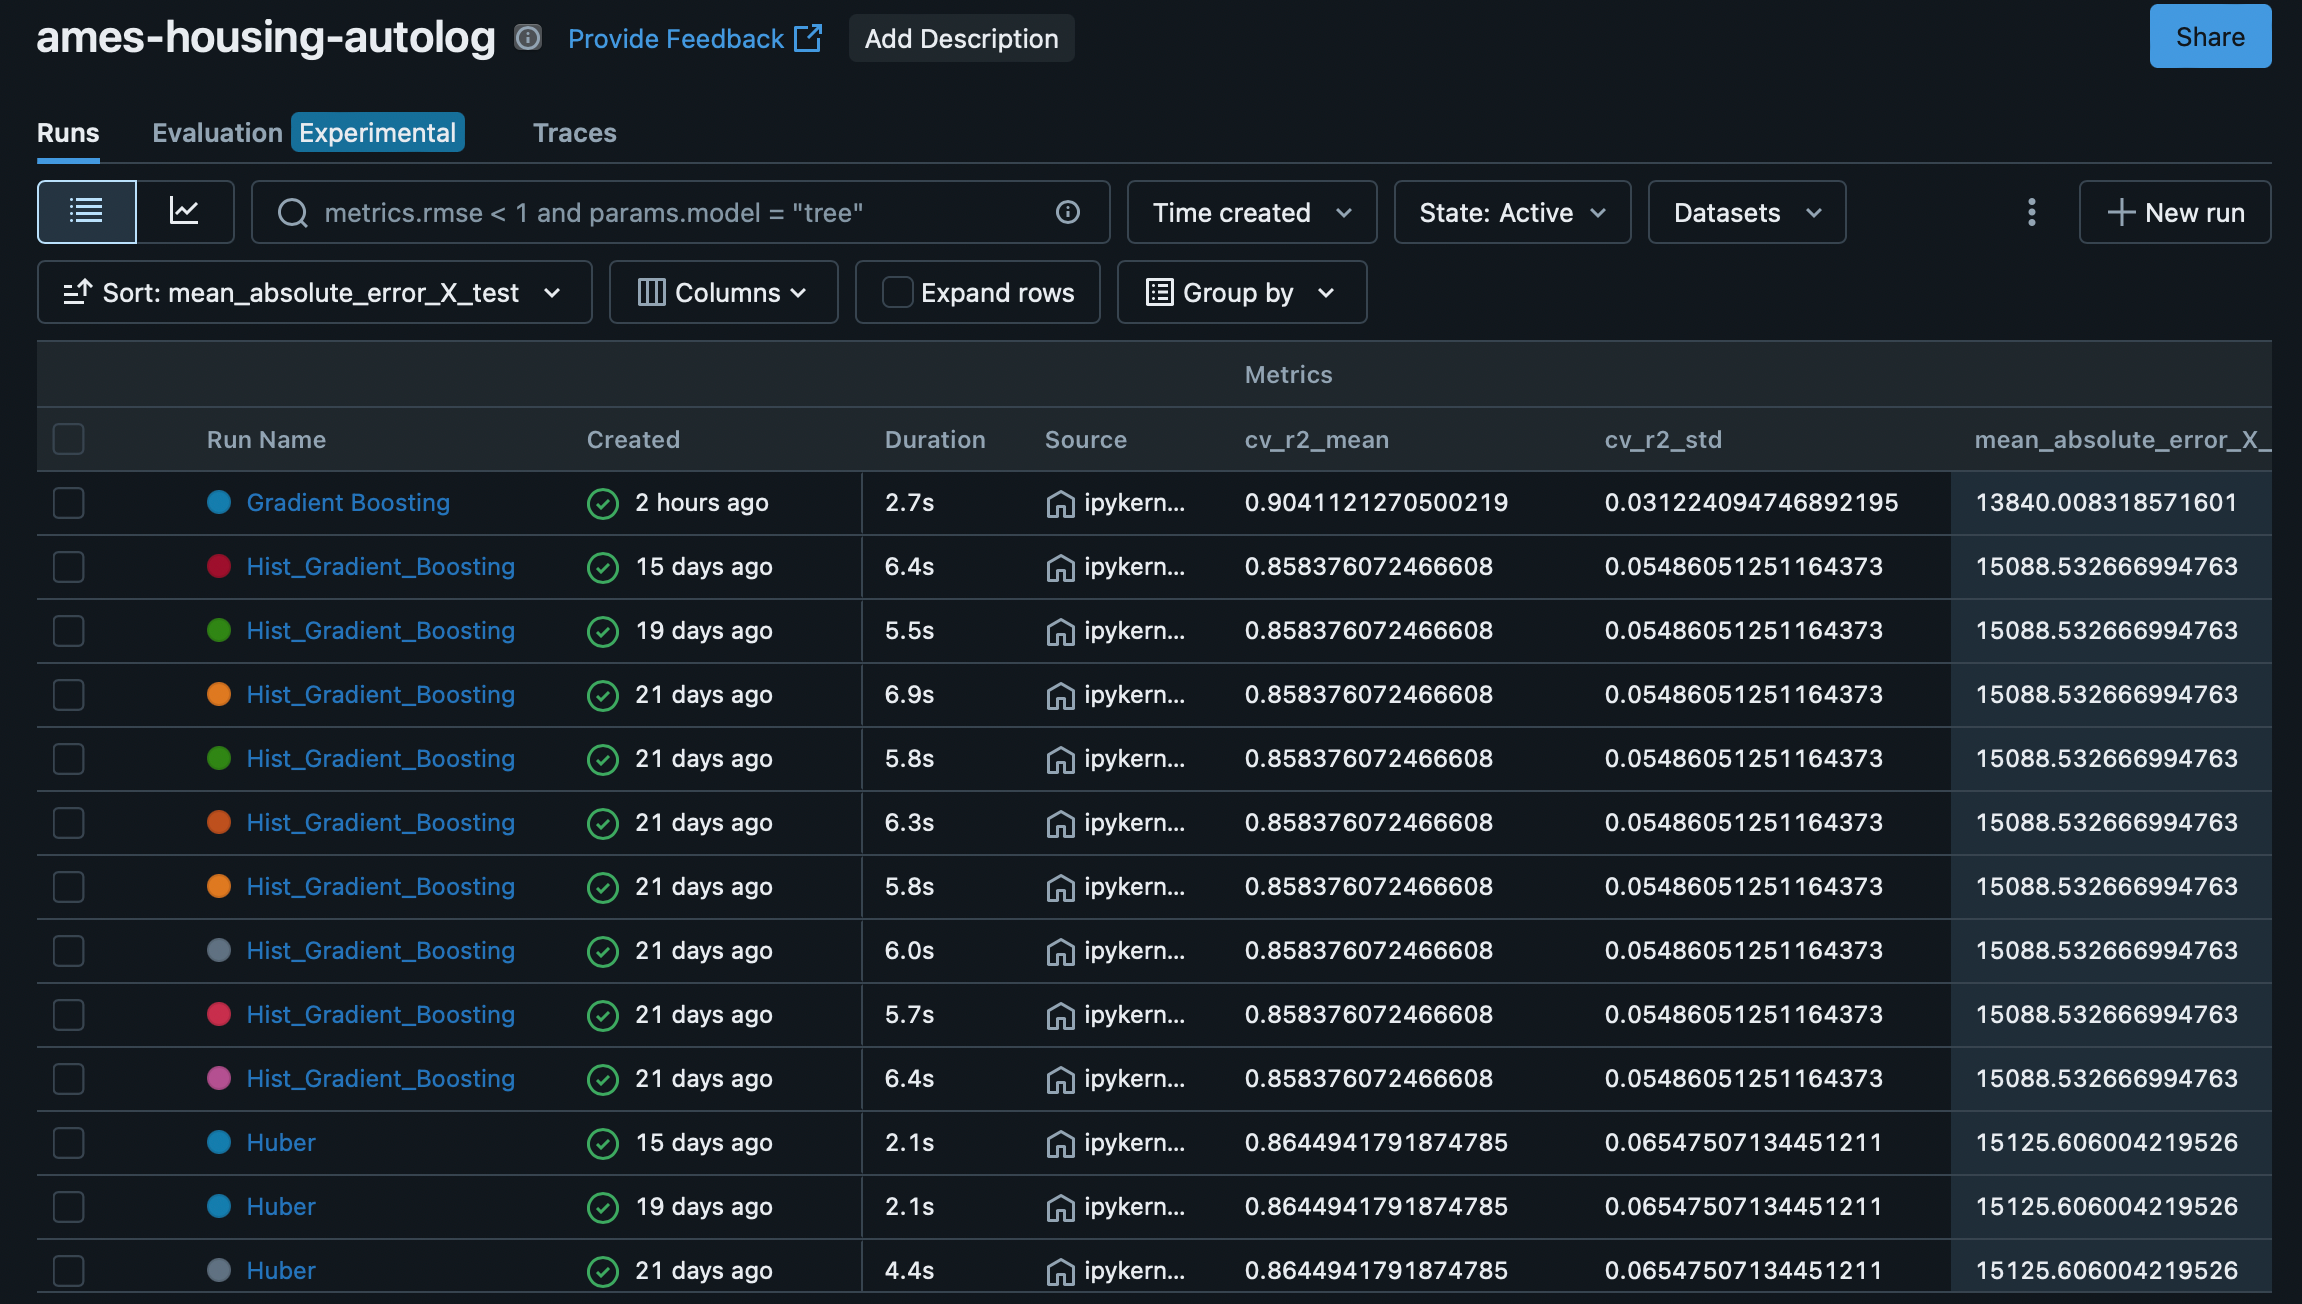

## 2.3 Connecting DVC and MLflow

You've already used DVC to version your dataset in the first part of this lab. Now let's connect DVC metadata with MLflow experiments to create a complete audit trail. When you run experiments, you want to know:
- Which version of the data was used?
- Can I reproduce these exact results?
- What changed between experiments?

By logging DVC metadata in MLflow, you create a link between your data versions and experiment results.

### Reading DVC metadata

DVC stores metadata in `.dvc` files. Let's read it:

In [9]:
import yaml

def get_dvc_metadata(dvc_file_path):
    with open(dvc_file_path, 'r') as f:
        dvc_data = yaml.safe_load(f)
    
    metadata = {
        'md5': dvc_data['outs'][0]['md5'],
        'size': dvc_data['outs'][0]['size'],
        'path': dvc_data['outs'][0]['path']
    }
    return metadata

dvc_metadata = get_dvc_metadata('data/ames_data_2006_2008.parquet.dvc')
print("DVC Metadata:")
print(f"MD5 hash: {dvc_metadata['md5']}")
print(f"File size: {dvc_metadata['size']} bytes")
print(f"Data path: {dvc_metadata['path']}")

DVC Metadata:
MD5 hash: f44053333f88a0646819936b37f000ee
File size: 162560 bytes
Data path: ames_data_2006_2008.parquet


### Exercise 1 - Logging DVC metadata in MLflow

We have trained 5 different models. The results of all of them can now be compared in MLflow. Now let's modify our training to include DVC metadata. This creates a complete audit trail:
- **Git commit** → tracks code version
- **DVC hash** → tracks data version
- **MLflow run** → tracks experiment results

Your task is to:
1. Run 5 more experiments with different parameters and models from scikit-learn. You can use any [supervised learning methods from scikit-learn](https://scikit-learn.org/stable/supervised_learning.html). Find some other models or parameters to tune our current models with and run the experiments again. 
2. Use the function `fit_sklearn_models_with_cv()` created above, or you can write your own if you want.
3. Make sure you have included DVC metadata logging. You can initialize dvc_metadata by calling above defined `get_dvc_metadata` function with the .dvc metadata file. Then you can just for each experiment add param logging like:

```python
mlflow.log_param("param_name", "value you want to log") # e.g md5
```

In [11]:
from sklearn.linear_model import Lasso, LassoLars, HuberRegressor, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, AdaBoostRegressor

In [12]:
additional_models = [
    ("Huber", HuberRegressor(max_iter=1000)),
    ("Lasso_alpha_0.1", Lasso(alpha=0.1)),
    ("Lasso_alpha_1.0", Lasso(alpha=1.0)),
    ("Ridge_alpha_1.0", Ridge(alpha=1.0)),
    ("Ridge_alpha_10.0", Ridge(alpha=10.0)),
    ("ElasticNet", ElasticNet(alpha=0.1)),
    ("Decision_Tree_depth_5", DecisionTreeRegressor(max_depth=5)),
    ("Decision_Tree_depth_10", DecisionTreeRegressor(max_depth=10)),
    ("Hist_Gradient_Boosting", HistGradientBoostingRegressor(max_iter=100)),
    ("Ada_Boost", AdaBoostRegressor(n_estimators=100)),
    ("LARS_Lasso", LassoLars(alpha=.1)),
]

In [13]:
fit_sklearn_models_with_cv(additional_models, X_train, X_test, y_train, y_test)

2026/04/09 01:04:40 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 01:04:41 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 01:04:42 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 01:04:42 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 01:04:42 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 01:04:42 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 01:04:42 WARNING mlflow.sklearn: Failed t


Huber:
  RMSE: 22952.96
  MAE: 15223.28
  R^2: 0.908
  CV R^2 (mean ± std): 0.893 ± 0.026
🏃 View run Huber at: http://localhost:5001/#/experiments/1/runs/f280f86ac7514bf9affb8f415435cf13
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/04/09 01:04:43 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 01:04:43 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 01:04:43 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 01:04:43 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 01:04:43 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 01:04:43 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 01:04:43 WARNING mlflow.sklearn: Failed t


Lasso_alpha_0.1:
  RMSE: 24077.53
  MAE: 16759.25
  R^2: 0.899
  CV R^2 (mean ± std): 0.867 ± 0.074
🏃 View run Lasso_alpha_0.1 at: http://localhost:5001/#/experiments/1/runs/84eeacc4a74c460ba08ebe8479aa3b8d
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/04/09 01:04:43 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 01:04:43 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 01:04:44 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 01:04:44 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 01:04:44 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 01:04:44 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 01:04:44 WARNING mlflow.sklearn: Failed t

...


Hist_Gradient_Boosting:
  RMSE: 22857.71
  MAE: 14258.98
  R^2: 0.909
  CV R^2 (mean ± std): 0.901 ± 0.039
🏃 View run Hist_Gradient_Boosting at: http://localhost:5001/#/experiments/1/runs/41d94f37b4094e64b85cf97c610815dc
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/04/09 01:04:51 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 01:04:52 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 01:04:52 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 01:04:52 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 01:04:53 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 01:04:53 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 01:04:53 WARNING mlflow.sklearn: Failed t


Ada_Boost:
  RMSE: 31605.59
  MAE: 22372.10
  R^2: 0.825
  CV R^2 (mean ± std): 0.825 ± 0.068
🏃 View run Ada_Boost at: http://localhost:5001/#/experiments/1/runs/e48db47bf9f642929e157870860299cf
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/04/09 01:04:53 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 01:04:53 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



LARS_Lasso:
  RMSE: 22696.73
  MAE: 15711.80
  R^2: 0.910
  CV R^2 (mean ± std): 0.889 ± 0.035
🏃 View run LARS_Lasso at: http://localhost:5001/#/experiments/1/runs/8b1ba29e37c948f8b40d1dc1210431ef
🧪 View experiment at: http://localhost:5001/#/experiments/1


![2. Exercise 1.png](screenshots/2.%20Exercise%201.png)

## 3. Manual logging with PyTorch

In this section, we'll implement manual logging for PyTorch models. While scikit-learn has autologging, PyTorch requires manual tracking - giving us full control over what and when to log. MLflow supports autologging for [PyTorch Lightning](https://lightning.ai/docs/pytorch/stable/), but we often need low-level control of pure PyTorch.

Note that we need to turn off scikit-learn autologging! Since we are using a Jupyter Notebook, MLflow uses the previously configured autologging unless explicitly turned off.

In [14]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold

# disable sklearn autologging!
mlflow.sklearn.autolog(disable=True)

mlflow.set_experiment("pytorch-housing-manual")

2026/04/09 01:07:29 INFO mlflow.tracking.fluent: Experiment with name 'pytorch-housing-manual' does not exist. Creating a new experiment.


<Experiment: artifact_location='/Users/bartoszkordek/PycharmProjects/MLOps_course_lab5/mlflow-artifacts/2', creation_time=1775689649727, experiment_id='2', last_update_time=1775689649727, lifecycle_stage='active', name='pytorch-housing-manual', tags={}>

### 3.1 Targets transformation

Before training the neural network, we will transform the training target, in order to stabilize the training. To see why, let's plot the house prices:

<Axes: ylabel='Frequency'>

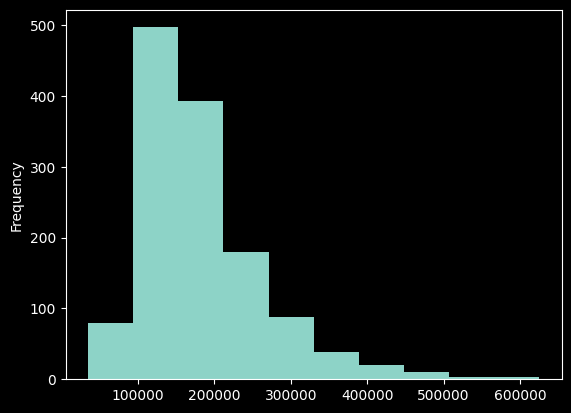

In [15]:
y_train.plot.hist()

Training on such targets is possible, but very large target values easily risk overflow, particularly when a loss function like mean squared error is used. We will use the log-transform to transform this distribution, as it's near-exponential, so it should bring it closer to normal, and also greatly reduce the values range.

Of course, we will need to transform the network predictions back again to evaluate them.

<Axes: ylabel='Frequency'>

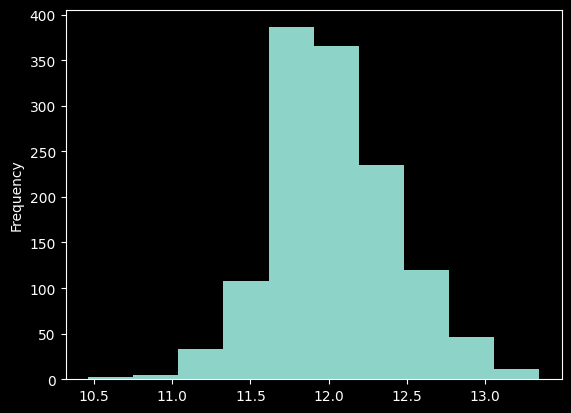

In [16]:
y_train_log = np.log1p(y_train)

pd.Series(y_train_log).plot.hist()

### 3.2 Define and train the model

Since we have tabular data, we will use a simple 2-layer multilayer perceptron (MLP).

In [17]:
class HousePriceNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout_rate=0.2):
        super(HousePriceNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

For training, we will check both the 5-fold CV performance, and the traditional train-test split. Cross-validation will give us an additional, robust performance estimation, as well as standard deviation, which is useful for comparing performances of different models. After all, if the difference between models would be within one standard deviation, it wouldn't really be meaningful.


In [18]:
import torch.nn as nn


class PyTorchTrainer:
    def __init__(
        self, model_class: type[nn.Module], config: dict
    ):
        required_keys = ['hidden_units', 'dropout', 'batch_size', 'learning_rate', 
                         'log_interval', 'epochs', 'name']
        missing = [key for key in required_keys if key not in config]
        if missing:
            raise ValueError(f"Missing required config keys: {missing}")
        
        self.model_class = model_class
        self.config = config

    def create_model(self, input_dim: int) -> nn.Module:
        return self.model_class(
            input_dim=input_dim,
            hidden_dim=self.config["hidden_units"],
            dropout_rate=self.config["dropout"],
        )

    def create_data_loader(
        self, X: torch.Tensor, y: torch.Tensor, shuffle: bool = True
    ) -> DataLoader:
        dataset = TensorDataset(X, y)
        return DataLoader(
            dataset, batch_size=self.config["batch_size"], shuffle=shuffle
        )

    def train_epoch(
        self,
        model: nn.Module,
        train_loader: DataLoader,
        criterion: nn.Module,
        optimizer: optim.Optimizer,
    ) -> float:
        model.train()
        epoch_loss = 0.0
        batch_count = 0

        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            batch_count += 1

        return epoch_loss / batch_count

    def train_model(
        self,
        model: nn.Module,
        train_loader: DataLoader,
        epochs: int,
        metric_prefix: str = "",
    ) -> None:
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=self.config["learning_rate"])

        for epoch in range(epochs):
            avg_mse = self.train_epoch(model, train_loader, criterion, optimizer)

            if epoch % self.config["log_interval"] == 0:
                metric_name = (
                    f"{metric_prefix}train_mse" if metric_prefix else "train_mse"
                )
                # manually log metric value, with a given name and step value
                mlflow.log_metric(metric_name, avg_mse, step=epoch)

    @torch.no_grad()
    def evaluate_model(
        self,
        model: nn.Module,
        X: torch.Tensor,
        y_test: torch.Tensor,
        log_prefix: str = "",
    ) -> dict[str, float]:
        model.eval()
        
        y_pred_norm = model(X)

        # revert the logarithm with exponent
        y_pred = np.expm1(y_pred_norm.numpy())
        y_test = y_test.numpy()

        rmse = root_mean_squared_error(y_test.ravel(), y_pred.ravel())
        mae = mean_absolute_error(y_test.ravel(), y_pred.ravel())
        r2 = r2_score(y_test.ravel(), y_pred.ravel())

        if log_prefix:
            # manually log metrics that we want
            mlflow.log_metric(f"{log_prefix}_rmse", rmse)
            mlflow.log_metric(f"{log_prefix}_mae", mae)
            mlflow.log_metric(f"{log_prefix}_r2", r2)

        return {"rmse": rmse, "mae": mae, "r2": r2}

    def run_cross_validation(
        self, X_train: torch.Tensor, y_train: torch.Tensor, n_splits: int = 5
    ) -> tuple[float, float, list[float]]:
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        cv_scores = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
            print(f"\nTraining Fold {fold + 1}/{n_splits}...")

            X_fold_train = X_train[train_idx]
            y_fold_train = y_train[train_idx]
            X_fold_val = X_train[val_idx]
            y_fold_val = y_train[val_idx]

            fold_model = self.create_model(X_train.shape[1])
            fold_loader = self.create_data_loader(X_fold_train, y_fold_train)

            self.train_model(
                fold_model,
                fold_loader,
                self.config["epochs"],
                metric_prefix=f"fold_{fold + 1}_",
            )

            # transform validation data with exponent back to original unit
            y_fold_val = np.expm1(y_fold_val)
            
            val_metrics = self.evaluate_model(
                fold_model, X_fold_val, y_fold_val, log_prefix=f"fold_{fold + 1}_val"
            )

            cv_scores.append(val_metrics["r2"])
            print(
                f"  Fold {fold + 1} "
                f"Validation - RMSE: {val_metrics['rmse']:.2f}, "
                f"MAE: {val_metrics['mae']:.2f} "
                f"R^2: {val_metrics['r2']:.3f}"
            )

        return np.mean(cv_scores), np.std(cv_scores), cv_scores

    def _log_dvc_metadata(self, dvc_file_path: str = 'data/ames_data_2006_2008.parquet.dvc'):
        try:
            dvc_metadata = get_dvc_metadata(dvc_file_path)
            
            mlflow.log_param("data_dvc_md5", dvc_metadata['md5'])
            mlflow.log_param("data_dvc_size", dvc_metadata['size'])
            mlflow.log_param("data_path", dvc_metadata['path'])
            print(f"Logged DVC metadata: {dvc_metadata['md5'][:8]}...")
        except FileNotFoundError:
            print("DVC file not found - skipping metadata logging")
        except Exception as e:
            print(f"Could not log DVC metadata: {e}")

    def fit(
        self,
        X_train: pd.DataFrame | np.ndarray,
        y_train: pd.Series | np.ndarray,
        X_test: pd.DataFrame | np.ndarray,
        y_test: pd.Series | np.ndarray,
    ) -> dict:
        X_train, X_test, y_train, y_test = self._prepare_tensors(
            X_train, X_test, y_train, y_test
        )

        with mlflow.start_run(run_name=self.config["name"]):
            mlflow.log_params(self.config)
            
            # Log DVC metadata for data versioning
            self._log_dvc_metadata()

            print(f"Starting 5-fold cross-validation for {self.config['name']}...")
            cv_mean, cv_std, cv_scores = self.run_cross_validation(X_train, y_train)

            mlflow.log_metric("cv_r2_mean", cv_mean)
            mlflow.log_metric("cv_r2_std", cv_std)

            print(
                f"\nCross-validation complete. Mean R^2: {cv_mean:.3f} (+/- {cv_std:.3f})"
            )
            print("\nTraining final model on all training data...")

            final_model = self.create_model(X_train.shape[1])
            final_loader = self.create_data_loader(X_train, y_train)

            self.train_model(
                final_model,
                final_loader,
                self.config["epochs"],
                metric_prefix="final_model_",
            )

            print("\nEvaluating on test set...")
            test_metrics = self.evaluate_model(final_model, X_test, y_test)

            mlflow.log_metric("test_rmse", test_metrics["rmse"])
            mlflow.log_metric("test_mae", test_metrics["mae"])
            mlflow.log_metric("test_r2", test_metrics["r2"])

            self._print_results(test_metrics, cv_mean, cv_std)

            return {
                "rmse": test_metrics["rmse"],
                "mae": test_metrics["mae"],
                "r2": test_metrics["r2"],
                "cv_r2_mean": cv_mean,
                "cv_r2_std": cv_std,
                "cv_scores": cv_scores,
            }

    def _prepare_tensors(self, X_train, X_test, y_train, y_test) -> tuple:
        y_train = np.array(y_train)
        y_test = np.array(y_test)
        
        X_train_tensor = torch.FloatTensor(X_train)
        y_train_tensor = torch.FloatTensor(y_train.reshape(-1, 1))
        
        X_test_tensor = torch.FloatTensor(X_test)
        y_test_tensor = torch.FloatTensor(y_test.reshape(-1, 1))

        print(f"Training samples: {X_train_tensor.shape[0]}")
        print(f"Input features: {X_train_tensor.shape[1]}")
        
        return X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor
    
    def _print_results(
        self, test_metrics: dict[str, float], cv_mean: float, cv_std: float
    ) -> None:
        print(f"{'=' * 50}\n")
        print(f"  Mean R^2: {cv_mean:.3f} (+/- {cv_std:.3f})")
        print("\nCross-Validation Performance:")
        print(f"  R^2: {test_metrics['r2']:.3f}")
        print(f"  RMSE: {test_metrics['rmse']:.2f}")
        print(f"  MAE: {test_metrics['mae']:.2f}")
        print("Test Set Performance:")
        print(f"{'=' * 50}")
        print(f"FINAL RESULTS for {self.config['name']}:")
        print(f"\n{'=' * 50}")

Quite a bit of code there! So now let's train the model.

### Configuration 
`base_config` contains **fixed parameters** that stay the same across all experiments:
- `model_class`: The neural network architecture we're using (HousePriceNet)
- `random_seed`: For reproducibility (42)
- `log_interval`: How often to log metrics during training (every 5 epochs)
- `num_samples`: Dataset size
- `input_features`: Number of input features
- `k_folds`: Number of cross-validation folds (5)

`experiment_config` contains **hyperparameters** we want to tune:
- `name`: Unique identifier for this experiment run
- `hidden_units`: Size of the hidden layer (128, 256, 512, etc.)
- `dropout`: Dropout rate for regularization (0.0 to 0.5)
- `learning_rate`: Step size for gradient descent (0.001 to 0.1)
- `epochs`: Number of training iterations (50, 100, 150, etc.)
- `batch_size`: Number of samples per training batch (16, 32, 64, etc.)

If you want you can deliver your own NeuralNetwork model, and just specify in experiment_config: `{"model_class": YourOwnModel}` it will overwrite the our base `HousePriceNet`


#### 3. Merging configurations
We use Python's dictionary merge operator `|` to combine them:
```python
training_config = base_config | experiment_config
```

This creates a single configuration dictionary with all parameters. The `experiment_config` values override any duplicate keys from `base_config`, allowing us to easily experiment with different hyperparameters while keeping the base setup constant.

Now let's set up our first experiment:


In [20]:
base_config = {
    "model_class": HousePriceNet,
    "random_seed": 42,
    "log_interval": 5,
    "num_samples": X_train.shape[0],
    "input_features": X_train.shape[1],
    "k_folds": 5,
}

experiment_config = {
    "name": "first_run",
    "hidden_units": 128,
    "dropout": 0.1,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,
}

In [21]:
training_config = base_config | experiment_config

trainer = PyTorchTrainer(training_config["model_class"], training_config)
trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for first_run...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 28544.47, MAE: 21127.40 R^2: 0.887

Training Fold 2/5...
  Fold 2 Validation - RMSE: 33542.17, MAE: 24918.25 R^2: 0.816

Training Fold 3/5...
  Fold 3 Validation - RMSE: 29005.71, MAE: 20075.88 R^2: 0.875

Training Fold 4/5...
  Fold 4 Validation - RMSE: 30991.09, MAE: 21091.90 R^2: 0.832

Training Fold 5/5...
  Fold 5 Validation - RMSE: 31667.42, MAE: 23792.62 R^2: 0.827

Cross-validation complete. Mean R^2: 0.847 (+/- 0.028)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.847 (+/- 0.028)

Cross-Validation Performance:
  R^2: 0.906
  RMSE: 23125.09
  MAE: 15901.81
Test Set Performance:
FINAL RESULTS for first_run:

🏃 View run first_run at: http://localhost:5001/#/experiments/2/runs/cb2ede363d304fd6b55f26b442272420
🧪 View experiment at: http://localhost:5001/#/experiments/2

{'rmse': 23125.091796875,
 'mae': 15901.814453125,
 'r2': 0.906405508518219,
 'cv_r2_mean': np.float64(0.847319221496582),
 'cv_r2_std': np.float64(0.028188477506177347),
 'cv_scores': [0.8870972394943237,
  0.8155912756919861,
  0.8746588230133057,
  0.8318970203399658,
  0.8273517489433289]}

![3.2. first run.png](screenshots/3.2.%20first%20run.png)

### Exercise 2

Your task is to:
1. Run 10 experiments by modifying the hyperparameter configuration. Try to improve model performance, which is currently overfitted.
2. Analyze results in MLflow UI.
3. Comment on what changes impacted the model performance the most, and what changes disrupted the training process.
4. Compare the results of our first scikit-learn configuration with the first PyTorch experiments. Do you see any overfitting in the first PyTorch experiment? Explain what signs of overfitting can indicate this situation.

**How to modify configurations:**

You have two approaches:

#### Approach 1: Loop through multiple configurations (Recommended for systematic exploration)

Define a list of experiment configurations and iterate through them. Each configuration dictionary should contain only the hyperparameters you want to tune (name, hidden_units, dropout, learning_rate, epochs, batch_size). The base_config stays the same.

```python
base_config = {
    "model_class": HousePriceNet,  
    "random_seed": 42,             
    "log_interval": 5,             
    "input_features": X_train.shape[1],  # Number of features (181)
    "num_samples": X_train.shape[0],     # Dataset size (1312)
    "target_normalized": True,      
    "k_folds": 5,                  
}

# Define multiple experiments to run
configs = [
    {
        "name": "baseline_128_units",
        "hidden_units": 128,
        "dropout": 0.1,
        "learning_rate": 0.03,
        "epochs": 150,
        "batch_size": 32,
    },
    {
        "name": "larger_network_256",
        "hidden_units": 256,        # Try larger network
        "dropout": 0.2,             # More dropout for regularization
        "learning_rate": 0.01,      # Lower learning rate
        "epochs": 200,
        "batch_size": 64,    
    },
    {
        "name": "high_regularization",
        "hidden_units": 128,
        "dropout": 0.3,             # Even more dropout
        "learning_rate": 0.01,
        "epochs": 150,
        "batch_size": 32,
    },
    # Add 7 more configurations here...
]

# Run all experiments
for experiment_config in configs:
    training_config = base_config | experiment_config 
    
    trainer = PyTorchTrainer(training_config["model_class"], training_config)
    results = trainer.fit(X_train, y_train_log, X_test, y_test)
```

#### Approach 2: Manual and incremental (Good for quick iterations)

Run experiments one by one, adjusting hyperparameters based on previous results:

```python
# First experiment
experiment_config = {
    "name": "experiment_01_baseline",
    "hidden_units": 128,
    "dropout": 0.1,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,    
}

training_config = base_config | experiment_config 
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)
```
After analyzing results in MLflow, run another experiment

```
experiment_config = {
    "name": "experiment_02_more_dropout",
    "hidden_units": 128,
    "dropout": 0.3,  # Increased from 0.1
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,    
}

training_config = base_config | experiment_config 
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

# Continue with more experiments
```


**Tips for hyperparameter tuning:**
- Start with one change at a time to understand its impact
- Use meaningful experiment names that describe what you changed
- Check MLflow UI after each experiment to guide your next choice
- Look for signs of overfitting: high training performance but poor test performance
- Watch the training curves in MLflow's "Model metrics" tab 


### Lab assessment

Fill the code exercises in this Jupyter notebook, and send it with completed exercises, written comments in Markdown cells (particularly for questions in exercise 2), and screenshots of results in MLflow.


### Starting configuration

In [22]:
experiment_config = {
    "name": "exp01_dropout_03",
    "hidden_units": 128,
    "dropout": 0.3,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp01_dropout_03...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 25675.23, MAE: 18102.82 R^2: 0.909

Training Fold 2/5...
  Fold 2 Validation - RMSE: 19548.57, MAE: 13329.64 R^2: 0.937

Training Fold 3/5...
  Fold 3 Validation - RMSE: 24873.83, MAE: 16126.52 R^2: 0.908

Training Fold 4/5...
  Fold 4 Validation - RMSE: 25351.12, MAE: 17344.77 R^2: 0.888

Training Fold 5/5...
  Fold 5 Validation - RMSE: 23830.30, MAE: 16023.32 R^2: 0.902

Cross-validation complete. Mean R^2: 0.909 (+/- 0.016)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.909 (+/- 0.016)

Cross-Validation Performance:
  R^2: 0.851
  RMSE: 29174.52
  MAE: 20198.44
Test Set Performance:
FINAL RESULTS for exp01_dropout_03:

🏃 View run exp01_dropout_03 at: http://localhost:5001/#/experiments/2/runs/76681e56b322423794dbb1ba9cbb82f4
🧪 View experiment at: http://localhost

In [23]:
experiment_config = {
    "name": "exp01_a_dropout_03_learning_rate_015_epochs_200",
    "hidden_units": 128,
    "dropout": 0.3,
    "learning_rate": 0.015,
    "epochs": 200,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp01_a_dropout_03_learning_rate_015_epochs_200...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 22656.30, MAE: 15719.79 R^2: 0.929

Training Fold 2/5...
  Fold 2 Validation - RMSE: 24597.37, MAE: 17584.52 R^2: 0.901

Training Fold 3/5...
  Fold 3 Validation - RMSE: 25193.73, MAE: 17607.43 R^2: 0.905

Training Fold 4/5...
  Fold 4 Validation - RMSE: 28716.63, MAE: 19605.24 R^2: 0.856

Training Fold 5/5...
  Fold 5 Validation - RMSE: 27624.08, MAE: 19560.12 R^2: 0.869

Cross-validation complete. Mean R^2: 0.892 (+/- 0.026)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.892 (+/- 0.026)

Cross-Validation Performance:
  R^2: 0.849
  RMSE: 29396.49
  MAE: 20988.18
Test Set Performance:
FINAL RESULTS for exp01_a_dropout_03_learning_rate_015_epochs_200:

🏃 View run exp01_a_dropout_03_learning_rate_015_epochs_200 at: http://localhost:5001

In [25]:
experiment_config = {
    "name": "exp02_dropout_03_hidden_units_256",
    "hidden_units": 256,
    "dropout": 0.3,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp02_dropout_03_hidden_units_256...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 25379.45, MAE: 16930.85 R^2: 0.911

Training Fold 2/5...
  Fold 2 Validation - RMSE: 21848.19, MAE: 14948.02 R^2: 0.922

Training Fold 3/5...
  Fold 3 Validation - RMSE: 26413.44, MAE: 17586.79 R^2: 0.896

Training Fold 4/5...
  Fold 4 Validation - RMSE: 31620.21, MAE: 22652.31 R^2: 0.825

Training Fold 5/5...
  Fold 5 Validation - RMSE: 36727.28, MAE: 25183.57 R^2: 0.768

Cross-validation complete. Mean R^2: 0.864 (+/- 0.059)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.864 (+/- 0.059)

Cross-Validation Performance:
  R^2: 0.898
  RMSE: 24092.54
  MAE: 17007.39
Test Set Performance:
FINAL RESULTS for exp02_dropout_03_hidden_units_256:

🏃 View run exp02_dropout_03_hidden_units_256 at: http://localhost:5001/#/experiments/2/runs/8d2250f2af9a405db975

In [26]:
experiment_config = {
    "name": "exp02_a_hidden_units_256_learning_rate_0005_epochs_300",
    "hidden_units": 256,
    "dropout": 0.3,
    "learning_rate": 0.005,
    "epochs": 300,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp02_a_hidden_units_256_learning_rate_0005_epochs_300...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 45814.80, MAE: 35941.95 R^2: 0.709

Training Fold 2/5...
  Fold 2 Validation - RMSE: 60024.64, MAE: 44097.11 R^2: 0.409

Training Fold 3/5...
  Fold 3 Validation - RMSE: 32101.61, MAE: 22378.88 R^2: 0.846

Training Fold 4/5...
  Fold 4 Validation - RMSE: 38348.75, MAE: 27111.29 R^2: 0.743

Training Fold 5/5...
  Fold 5 Validation - RMSE: 42363.61, MAE: 29107.17 R^2: 0.691

Cross-validation complete. Mean R^2: 0.680 (+/- 0.145)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.680 (+/- 0.145)

Cross-Validation Performance:
  R^2: 0.881
  RMSE: 26060.79
  MAE: 17718.72
Test Set Performance:
FINAL RESULTS for exp02_a_hidden_units_256_learning_rate_0005_epochs_300:

🏃 View run exp02_a_hidden_units_256_learning_rate_0005_epochs_300 at: 

In [27]:
experiment_config = {
    "name": "exp02_hidden_units_64_dropout_02_learning_rate_0001_epochs_200_batch_size_64",
    "hidden_units": 64,
    "dropout": 0.2,
    "learning_rate": 0.001,
    "epochs": 200,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp02_hidden_units_64_dropout_02_learning_rate_0001_epochs_200_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 46730.59, MAE: 35863.93 R^2: 0.697

Training Fold 2/5...
  Fold 2 Validation - RMSE: 58647.68, MAE: 41476.96 R^2: 0.436

Training Fold 3/5...
  Fold 3 Validation - RMSE: 52988.76, MAE: 41272.82 R^2: 0.582

Training Fold 4/5...
  Fold 4 Validation - RMSE: 63565.11, MAE: 41795.55 R^2: 0.293

Training Fold 5/5...
  Fold 5 Validation - RMSE: 47638.07, MAE: 34917.79 R^2: 0.609

Cross-validation complete. Mean R^2: 0.523 (+/- 0.143)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.523 (+/- 0.143)

Cross-Validation Performance:
  R^2: 0.607
  RMSE: 47389.75
  MAE: 36551.07
Test Set Performance:
FINAL RESULTS for exp02_hidden_units_64_dropout_02_learning_rate_0001_epochs_200_batch_size_64:

🏃 View run exp02_hidden_un

In [26]:
experiment_config = {
    "name": "exp03_dropout_04_hidden_units_512",
    "hidden_units": 512,
    "dropout": 0.4,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp03_dropout_04_hidden_units_512...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 36176.63, MAE: 22544.13 R^2: 0.853

Training Fold 2/5...
  Fold 2 Validation - RMSE: 31105.65, MAE: 20210.44 R^2: 0.849

Training Fold 3/5...
  Fold 3 Validation - RMSE: 51441.39, MAE: 23056.53 R^2: 0.645

Training Fold 4/5...
  Fold 4 Validation - RMSE: 30698.28, MAE: 21773.21 R^2: 0.837

Training Fold 5/5...
  Fold 5 Validation - RMSE: 54005.13, MAE: 19075.86 R^2: 0.467

Cross-validation complete. Mean R^2: 0.730 (+/- 0.153)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.730 (+/- 0.153)

Cross-Validation Performance:
  R^2: 0.669
  RMSE: 43425.79
  MAE: 24064.59
Test Set Performance:
FINAL RESULTS for exp03_dropout_04_hidden_units_512:

🏃 View run exp03_dropout_04_hidden_units_512 at: http://localhost:5001/#/experiments/2/runs/7680266c988a4ffb923b

In [28]:
experiment_config = {
    "name": "exp04_learning_rate_005",
    "hidden_units": 128,
    "dropout": 0.1,
    "learning_rate": 0.05,
    "epochs": 150,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp04_learning_rate_005...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 31667.57, MAE: 22082.95 R^2: 0.861

Training Fold 2/5...
  Fold 2 Validation - RMSE: 45136.80, MAE: 30898.02 R^2: 0.666

Training Fold 3/5...
  Fold 3 Validation - RMSE: 23911.59, MAE: 16243.08 R^2: 0.915

Training Fold 4/5...
  Fold 4 Validation - RMSE: 23746.15, MAE: 15280.35 R^2: 0.901

Training Fold 5/5...
  Fold 5 Validation - RMSE: 22360.57, MAE: 15599.84 R^2: 0.914

Cross-validation complete. Mean R^2: 0.851 (+/- 0.095)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.851 (+/- 0.095)

Cross-Validation Performance:
  R^2: 0.899
  RMSE: 24030.75
  MAE: 16647.63
Test Set Performance:
FINAL RESULTS for exp04_learning_rate_005:

🏃 View run exp04_learning_rate_005 at: http://localhost:5001/#/experiments/2/runs/13b03cc29de245e38cce0ada8639c92f
🧪 View experiment

In [29]:
experiment_config = {
    "name": "exp05_epochs_250",
    "hidden_units": 128,
    "dropout": 0.1,
    "learning_rate": 0.03,
    "epochs": 250,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp05_epochs_250...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 28562.01, MAE: 18963.00 R^2: 0.887

Training Fold 2/5...
  Fold 2 Validation - RMSE: 20169.38, MAE: 15294.44 R^2: 0.933

Training Fold 3/5...
  Fold 3 Validation - RMSE: 28216.45, MAE: 17980.88 R^2: 0.881

Training Fold 4/5...
  Fold 4 Validation - RMSE: 27968.75, MAE: 19156.60 R^2: 0.863

Training Fold 5/5...
  Fold 5 Validation - RMSE: 31098.24, MAE: 21935.33 R^2: 0.834

Cross-validation complete. Mean R^2: 0.880 (+/- 0.033)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.880 (+/- 0.033)

Cross-Validation Performance:
  R^2: 0.849
  RMSE: 29381.68
  MAE: 20999.20
Test Set Performance:
FINAL RESULTS for exp05_epochs_250:

🏃 View run exp05_epochs_250 at: http://localhost:5001/#/experiments/2/runs/0f089ddd2f1d45868e0d4d4ee3926e53
🧪 View experiment at: http://localhost

In [30]:
experiment_config = {
    "name": "exp06_epochs_250_hidden_units_512_dropout_03_learning_rate_005",
    "hidden_units": 512,
    "dropout": 0.3,
    "learning_rate": 0.05,
    "epochs": 250,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp06_epochs_250_hidden_units_512_dropout_03_learning_rate_005...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 47318.87, MAE: 34666.27 R^2: 0.690

Training Fold 2/5...
  Fold 2 Validation - RMSE: 36772.93, MAE: 24684.11 R^2: 0.778

Training Fold 3/5...
  Fold 3 Validation - RMSE: 41262.57, MAE: 26785.21 R^2: 0.746

Training Fold 4/5...
  Fold 4 Validation - RMSE: 33487.54, MAE: 23473.33 R^2: 0.804

Training Fold 5/5...
  Fold 5 Validation - RMSE: 31076.89, MAE: 23514.14 R^2: 0.834

Cross-validation complete. Mean R^2: 0.770 (+/- 0.050)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.770 (+/- 0.050)

Cross-Validation Performance:
  R^2: 0.663
  RMSE: 43871.72
  MAE: 32655.01
Test Set Performance:
FINAL RESULTS for exp06_epochs_250_hidden_units_512_dropout_03_learning_rate_005:

🏃 View run exp06_epochs_250_hidden_units_512_dropout_0

In [31]:
experiment_config = {
    "name": "exp07_epochs_100",
    "hidden_units": 128,
    "dropout": 0.1,
    "learning_rate": 0.03,
    "epochs": 100,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp07_epochs_100...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 56272.29, MAE: 42584.09 R^2: 0.561

Training Fold 2/5...
  Fold 2 Validation - RMSE: 105132.48, MAE: 70687.05 R^2: -0.812

Training Fold 3/5...
  Fold 3 Validation - RMSE: 48929.05, MAE: 35245.41 R^2: 0.643

Training Fold 4/5...
  Fold 4 Validation - RMSE: 33043.45, MAE: 24730.42 R^2: 0.809

Training Fold 5/5...
  Fold 5 Validation - RMSE: 45869.94, MAE: 36876.79 R^2: 0.638

Cross-validation complete. Mean R^2: 0.368 (+/- 0.595)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.368 (+/- 0.595)

Cross-Validation Performance:
  R^2: 0.846
  RMSE: 29620.14
  MAE: 19666.69
Test Set Performance:
FINAL RESULTS for exp07_epochs_100:

🏃 View run exp07_epochs_100 at: http://localhost:5001/#/experiments/2/runs/4535eb609fa04eb1b7a1a0871a44479c
🧪 View experiment at: http://localho

In [32]:
experiment_config = {
    "name": "exp08_learning_rate_001",
    "hidden_units": 128,
    "dropout": 0.1,
    "learning_rate": 0.01,
    "epochs": 150,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp08_learning_rate_001...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 43235.33, MAE: 33319.13 R^2: 0.741

Training Fold 2/5...
  Fold 2 Validation - RMSE: 49382.79, MAE: 35895.04 R^2: 0.600

Training Fold 3/5...
  Fold 3 Validation - RMSE: 38642.36, MAE: 27987.85 R^2: 0.778

Training Fold 4/5...
  Fold 4 Validation - RMSE: 64467.75, MAE: 35005.53 R^2: 0.273

Training Fold 5/5...
  Fold 5 Validation - RMSE: 53141.03, MAE: 44520.31 R^2: 0.514

Cross-validation complete. Mean R^2: 0.581 (+/- 0.181)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.581 (+/- 0.181)

Cross-Validation Performance:
  R^2: 0.482
  RMSE: 54410.09
  MAE: 44627.57
Test Set Performance:
FINAL RESULTS for exp08_learning_rate_001:

🏃 View run exp08_learning_rate_001 at: http://localhost:5001/#/experiments/2/runs/495bca29d569489b92caefe1f56126b5
🧪 View experiment

In [33]:
experiment_config = {
    "name": "exp09_learning_rate_001_hidden_units_256_dropout_03",
    "hidden_units": 256,
    "dropout": 0.3,
    "learning_rate": 0.01,
    "epochs": 150,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp09_learning_rate_001_hidden_units_256_dropout_03...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 50647.51, MAE: 40303.87 R^2: 0.645

Training Fold 2/5...
  Fold 2 Validation - RMSE: 166453.70, MAE: 136557.39 R^2: -3.541

Training Fold 3/5...
  Fold 3 Validation - RMSE: 57394.27, MAE: 43966.84 R^2: 0.509

Training Fold 4/5...
  Fold 4 Validation - RMSE: 56091.89, MAE: 42909.48 R^2: 0.449

Training Fold 5/5...
  Fold 5 Validation - RMSE: 38263.40, MAE: 28197.50 R^2: 0.748

Cross-validation complete. Mean R^2: -0.238 (+/- 1.655)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: -0.238 (+/- 1.655)

Cross-Validation Performance:
  R^2: 0.800
  RMSE: 33822.95
  MAE: 25003.73
Test Set Performance:
FINAL RESULTS for exp09_learning_rate_001_hidden_units_256_dropout_03:

🏃 View run exp09_learning_rate_001_hidden_units_256_dropout_03 at: http

In [34]:
experiment_config = {
    "name": "exp10_hidden_units_64",
    "hidden_units": 64,
    "dropout": 0.1,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp10_hidden_units_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 25006.69, MAE: 17980.30 R^2: 0.913

Training Fold 2/5...
  Fold 2 Validation - RMSE: 31164.41, MAE: 24233.68 R^2: 0.841

Training Fold 3/5...
  Fold 3 Validation - RMSE: 29553.40, MAE: 22841.86 R^2: 0.870

Training Fold 4/5...
  Fold 4 Validation - RMSE: 23303.95, MAE: 16057.27 R^2: 0.905

Training Fold 5/5...
  Fold 5 Validation - RMSE: 29550.35, MAE: 22180.05 R^2: 0.850

Cross-validation complete. Mean R^2: 0.876 (+/- 0.029)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.876 (+/- 0.029)

Cross-Validation Performance:
  R^2: 0.909
  RMSE: 22762.00
  MAE: 15754.59
Test Set Performance:
FINAL RESULTS for exp10_hidden_units_64:

🏃 View run exp10_hidden_units_64 at: http://localhost:5001/#/experiments/2/runs/65f8af68e26a4a759e1514f7a2acf4d7
🧪 View experiment at: h

In [35]:
experiment_config = {
    "name": "exp11_hidden_units_96_dropout_05_learning_rate_001_epochs_250_batch_size_64",
    "hidden_units": 96,
    "dropout": 0.5,
    "learning_rate": 0.01,
    "epochs": 250,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_hidden_units_96_dropout_05_learning_rate_001_epochs_250_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 30874.97, MAE: 22030.59 R^2: 0.868

Training Fold 2/5...
  Fold 2 Validation - RMSE: 22582.61, MAE: 14689.51 R^2: 0.916

Training Fold 3/5...
  Fold 3 Validation - RMSE: 27121.75, MAE: 17577.49 R^2: 0.890

Training Fold 4/5...
  Fold 4 Validation - RMSE: 25775.45, MAE: 17642.57 R^2: 0.884

Training Fold 5/5...
  Fold 5 Validation - RMSE: 24588.52, MAE: 16931.08 R^2: 0.896

Cross-validation complete. Mean R^2: 0.891 (+/- 0.016)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.891 (+/- 0.016)

Cross-Validation Performance:
  R^2: 0.895
  RMSE: 24534.59
  MAE: 17067.88
Test Set Performance:
FINAL RESULTS for exp11_hidden_units_96_dropout_05_learning_rate_001_epochs_250_batch_size_64:

🏃 View run exp11_hidden_unit

In [36]:
experiment_config = {
    "name": "exp11_a_hidden_units_96_dropout_06_learning_rate_0008_epochs_250_batch_size_64",
    "hidden_units": 96,
    "dropout": 0.6,
    "learning_rate": 0.008,
    "epochs": 250,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_a_hidden_units_96_dropout_06_learning_rate_0008_epochs_250_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 25503.20, MAE: 17906.21 R^2: 0.910

Training Fold 2/5...
  Fold 2 Validation - RMSE: 22758.08, MAE: 14481.91 R^2: 0.915

Training Fold 3/5...
  Fold 3 Validation - RMSE: 36649.71, MAE: 22945.87 R^2: 0.800

Training Fold 4/5...
  Fold 4 Validation - RMSE: 23181.84, MAE: 15791.09 R^2: 0.906

Training Fold 5/5...
  Fold 5 Validation - RMSE: 25905.11, MAE: 17509.34 R^2: 0.884

Cross-validation complete. Mean R^2: 0.883 (+/- 0.043)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.883 (+/- 0.043)

Cross-Validation Performance:
  R^2: 0.883
  RMSE: 25826.67
  MAE: 17858.48
Test Set Performance:
FINAL RESULTS for exp11_a_hidden_units_96_dropout_06_learning_rate_0008_epochs_250_batch_size_64:

🏃 View run exp11_a_hid

In [37]:
experiment_config = {
    "name": "exp11_b_hidden_units_64_dropout_06_learning_rate_01_epochs_250_batch_size_64",
    "hidden_units": 64,
    "dropout": 0.6,
    "learning_rate": 0.1,
    "epochs": 250,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_b_hidden_units_64_dropout_06_learning_rate_01_epochs_250_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 28061.80, MAE: 20511.39 R^2: 0.891

Training Fold 2/5...
  Fold 2 Validation - RMSE: 43442.29, MAE: 30397.70 R^2: 0.691

Training Fold 3/5...
  Fold 3 Validation - RMSE: 56113.99, MAE: 40743.64 R^2: 0.531

Training Fold 4/5...
  Fold 4 Validation - RMSE: 33604.95, MAE: 22949.65 R^2: 0.802

Training Fold 5/5...
  Fold 5 Validation - RMSE: 41885.79, MAE: 31388.57 R^2: 0.698

Cross-validation complete. Mean R^2: 0.723 (+/- 0.121)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.723 (+/- 0.121)

Cross-Validation Performance:
  R^2: 0.572
  RMSE: 49479.82
  MAE: 32423.49
Test Set Performance:
FINAL RESULTS for exp11_b_hidden_units_64_dropout_06_learning_rate_01_epochs_250_batch_size_64:

🏃 View run exp11_b_hidden_

In [38]:
experiment_config = {
    "name": "exp11_c_hidden_units_96_dropout_06_learning_rate_0008_epochs_500_batch_size_64",
    "hidden_units": 96,
    "dropout": 0.6,
    "learning_rate": 0.008,
    "epochs": 500,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_c_hidden_units_96_dropout_06_learning_rate_0008_epochs_500_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 29554.42, MAE: 20668.74 R^2: 0.879

Training Fold 2/5...
  Fold 2 Validation - RMSE: 26251.52, MAE: 19072.82 R^2: 0.887

Training Fold 3/5...
  Fold 3 Validation - RMSE: 24176.56, MAE: 16559.85 R^2: 0.913

Training Fold 4/5...
  Fold 4 Validation - RMSE: 31427.21, MAE: 21136.19 R^2: 0.827

Training Fold 5/5...
  Fold 5 Validation - RMSE: 23002.58, MAE: 15830.77 R^2: 0.909

Cross-validation complete. Mean R^2: 0.883 (+/- 0.031)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.883 (+/- 0.031)

Cross-Validation Performance:
  R^2: 0.886
  RMSE: 25558.88
  MAE: 17514.70
Test Set Performance:
FINAL RESULTS for exp11_c_hidden_units_96_dropout_06_learning_rate_0008_epochs_500_batch_size_64:

🏃 View run exp11_c_hid

In [39]:
experiment_config = {
    "name": "exp11_a_hidden_units_112_dropout_06_learning_rate_0008_epochs_250_batch_size_64",
    "hidden_units": 112,
    "dropout": 0.6,
    "learning_rate": 0.008,
    "epochs": 250,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_a_hidden_units_112_dropout_06_learning_rate_0008_epochs_250_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 27122.69, MAE: 18555.47 R^2: 0.898

Training Fold 2/5...
  Fold 2 Validation - RMSE: 32587.48, MAE: 23212.12 R^2: 0.826

Training Fold 3/5...
  Fold 3 Validation - RMSE: 26107.15, MAE: 17786.04 R^2: 0.898

Training Fold 4/5...
  Fold 4 Validation - RMSE: 23882.26, MAE: 15736.81 R^2: 0.900

Training Fold 5/5...
  Fold 5 Validation - RMSE: 25005.39, MAE: 16621.67 R^2: 0.892

Cross-validation complete. Mean R^2: 0.883 (+/- 0.029)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.883 (+/- 0.029)

Cross-Validation Performance:
  R^2: 0.873
  RMSE: 26948.81
  MAE: 18786.27
Test Set Performance:
FINAL RESULTS for exp11_a_hidden_units_112_dropout_06_learning_rate_0008_epochs_250_batch_size_64:

🏃 View run exp11_a_h

In [40]:
experiment_config = {
    "name": "exp11_aa_hidden_units_112_dropout_06_learning_rate_0006_epochs_250_batch_size_64",
    "hidden_units": 112,
    "dropout": 0.6,
    "learning_rate": 0.006,
    "epochs": 250,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_aa_hidden_units_112_dropout_06_learning_rate_0006_epochs_250_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 39430.15, MAE: 29494.10 R^2: 0.785

Training Fold 2/5...
  Fold 2 Validation - RMSE: 41655.06, MAE: 31899.18 R^2: 0.716

Training Fold 3/5...
  Fold 3 Validation - RMSE: 31918.00, MAE: 20318.27 R^2: 0.848

Training Fold 4/5...
  Fold 4 Validation - RMSE: 30839.02, MAE: 21375.00 R^2: 0.834

Training Fold 5/5...
  Fold 5 Validation - RMSE: 37341.20, MAE: 27130.24 R^2: 0.760

Cross-validation complete. Mean R^2: 0.788 (+/- 0.048)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.788 (+/- 0.048)

Cross-Validation Performance:
  R^2: 0.905
  RMSE: 23279.39
  MAE: 15646.47
Test Set Performance:
FINAL RESULTS for exp11_aa_hidden_units_112_dropout_06_learning_rate_0006_epochs_250_batch_size_64:

🏃 View run exp11_a

In [41]:
experiment_config = {
    "name": "exp11_ab_hidden_units_112_dropout_06_learning_rate_0007_epochs_250_batch_size_64",
    "hidden_units": 112,
    "dropout": 0.6,
    "learning_rate": 0.007,
    "epochs": 250,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_ab_hidden_units_112_dropout_06_learning_rate_0007_epochs_250_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 24528.49, MAE: 16913.61 R^2: 0.917

Training Fold 2/5...
  Fold 2 Validation - RMSE: 30696.14, MAE: 22252.98 R^2: 0.846

Training Fold 3/5...
  Fold 3 Validation - RMSE: 42406.75, MAE: 29957.52 R^2: 0.732

Training Fold 4/5...
  Fold 4 Validation - RMSE: 24724.91, MAE: 16175.36 R^2: 0.893

Training Fold 5/5...
  Fold 5 Validation - RMSE: 29113.82, MAE: 20365.08 R^2: 0.854

Cross-validation complete. Mean R^2: 0.848 (+/- 0.064)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.848 (+/- 0.064)

Cross-Validation Performance:
  R^2: 0.893
  RMSE: 24749.87
  MAE: 16745.23
Test Set Performance:
FINAL RESULTS for exp11_ab_hidden_units_112_dropout_06_learning_rate_0007_epochs_250_batch_size_64:

🏃 View run exp11_a

In [42]:
experiment_config = {
    "name": "exp11_a_hidden_units_112_dropout_06_learning_rate_0007_epochs_300_batch_size_64",
    "hidden_units": 112,
    "dropout": 0.6,
    "learning_rate": 0.007,
    "epochs": 300,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_a_hidden_units_112_dropout_06_learning_rate_0007_epochs_300_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 24658.00, MAE: 17330.62 R^2: 0.916

Training Fold 2/5...
  Fold 2 Validation - RMSE: 21497.48, MAE: 13841.00 R^2: 0.924

Training Fold 3/5...
  Fold 3 Validation - RMSE: 29717.36, MAE: 18617.15 R^2: 0.868

Training Fold 4/5...
  Fold 4 Validation - RMSE: 26393.23, MAE: 17889.77 R^2: 0.878

Training Fold 5/5...
  Fold 5 Validation - RMSE: 27453.46, MAE: 18235.75 R^2: 0.870

Cross-validation complete. Mean R^2: 0.891 (+/- 0.024)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.891 (+/- 0.024)

Cross-Validation Performance:
  R^2: 0.898
  RMSE: 24194.04
  MAE: 16917.13
Test Set Performance:
FINAL RESULTS for exp11_a_hidden_units_112_dropout_06_learning_rate_0007_epochs_300_batch_size_64:

🏃 View run exp11_a_h

In [43]:
experiment_config = {
    "name": "exp11_a_hidden_units_112_dropout_06_learning_rate_0006_epochs_300_batch_size_64",
    "hidden_units": 112,
    "dropout": 0.6,
    "learning_rate": 0.006,
    "epochs": 300,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_a_hidden_units_112_dropout_06_learning_rate_0006_epochs_300_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 29218.07, MAE: 19907.71 R^2: 0.882

Training Fold 2/5...
  Fold 2 Validation - RMSE: 24225.81, MAE: 16575.32 R^2: 0.904

Training Fold 3/5...
  Fold 3 Validation - RMSE: 27696.75, MAE: 17109.30 R^2: 0.886

Training Fold 4/5...
  Fold 4 Validation - RMSE: 22397.60, MAE: 15180.94 R^2: 0.912

Training Fold 5/5...
  Fold 5 Validation - RMSE: 24300.01, MAE: 16376.49 R^2: 0.898

Cross-validation complete. Mean R^2: 0.896 (+/- 0.011)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.896 (+/- 0.011)

Cross-Validation Performance:
  R^2: 0.886
  RMSE: 25547.39
  MAE: 17832.40
Test Set Performance:
FINAL RESULTS for exp11_a_hidden_units_112_dropout_06_learning_rate_0006_epochs_300_batch_size_64:

🏃 View run exp11_a_h

In [44]:
experiment_config = {
    "name": "exp11_aca_hidden_units_112_dropout_065_learning_rate_00065_epochs_300_batch_size_64",
    "hidden_units": 112,
    "dropout": 0.65,
    "learning_rate": 0.0065,
    "epochs": 300,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_aca_hidden_units_112_dropout_065_learning_rate_00065_epochs_300_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 24361.77, MAE: 17098.65 R^2: 0.918

Training Fold 2/5...
  Fold 2 Validation - RMSE: 22059.72, MAE: 14583.53 R^2: 0.920

Training Fold 3/5...
  Fold 3 Validation - RMSE: 27037.96, MAE: 18225.44 R^2: 0.891

Training Fold 4/5...
  Fold 4 Validation - RMSE: 32522.65, MAE: 21517.99 R^2: 0.815

Training Fold 5/5...
  Fold 5 Validation - RMSE: 27058.60, MAE: 18531.95 R^2: 0.874

Cross-validation complete. Mean R^2: 0.884 (+/- 0.038)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.884 (+/- 0.038)

Cross-Validation Performance:
  R^2: 0.883
  RMSE: 25826.68
  MAE: 18684.54
Test Set Performance:
FINAL RESULTS for exp11_aca_hidden_units_112_dropout_065_learning_rate_00065_epochs_300_batch_size_64:

🏃 View run e

In [45]:
experiment_config = {
    "name": "exp11_acb_hidden_units_112_dropout_059_learning_rate_00059_epochs_300_batch_size_64",
    "hidden_units": 112,
    "dropout": 0.59,
    "learning_rate": 0.0059,
    "epochs": 300,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_acb_hidden_units_112_dropout_059_learning_rate_00059_epochs_300_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 30022.76, MAE: 20925.25 R^2: 0.875

Training Fold 2/5...
  Fold 2 Validation - RMSE: 31774.46, MAE: 22790.41 R^2: 0.835

Training Fold 3/5...
  Fold 3 Validation - RMSE: 32580.92, MAE: 20766.57 R^2: 0.842

Training Fold 4/5...
  Fold 4 Validation - RMSE: 25263.39, MAE: 16731.26 R^2: 0.888

Training Fold 5/5...
  Fold 5 Validation - RMSE: 26774.86, MAE: 17964.73 R^2: 0.877

Cross-validation complete. Mean R^2: 0.863 (+/- 0.021)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.863 (+/- 0.021)

Cross-Validation Performance:
  R^2: 0.900
  RMSE: 23931.88
  MAE: 16629.99
Test Set Performance:
FINAL RESULTS for exp11_acb_hidden_units_112_dropout_059_learning_rate_00059_epochs_300_batch_size_64:

🏃 View run e

In [46]:
experiment_config = {
    "name": "exp11_acd_hidden_units_112_dropout_0591_learning_rate_000591_epochs_300_batch_size_64",
    "hidden_units": 112,
    "dropout": 0.591,
    "learning_rate": 0.00591,
    "epochs": 300,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_acd_hidden_units_112_dropout_0591_learning_rate_000591_epochs_300_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 22390.52, MAE: 15758.86 R^2: 0.931

Training Fold 2/5...
  Fold 2 Validation - RMSE: 28377.29, MAE: 18933.94 R^2: 0.868

Training Fold 3/5...
  Fold 3 Validation - RMSE: 25318.05, MAE: 17025.54 R^2: 0.905

Training Fold 4/5...
  Fold 4 Validation - RMSE: 31797.84, MAE: 22030.71 R^2: 0.823

Training Fold 5/5...
  Fold 5 Validation - RMSE: 31368.63, MAE: 22050.93 R^2: 0.831

Cross-validation complete. Mean R^2: 0.871 (+/- 0.041)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.871 (+/- 0.041)

Cross-Validation Performance:
  R^2: 0.881
  RMSE: 26055.02
  MAE: 18264.39
Test Set Performance:
FINAL RESULTS for exp11_acd_hidden_units_112_dropout_0591_learning_rate_000591_epochs_300_batch_size_64:

🏃 View r

In [47]:
experiment_config = {
    "name": "exp11_ace_hidden_units_112_dropout_059_learning_rate_0005905_epochs_300_batch_size_64",
    "hidden_units": 112,
    "dropout": 0.59,
    "learning_rate": 0.005905,
    "epochs": 300,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_ace_hidden_units_112_dropout_059_learning_rate_0005905_epochs_300_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 22794.61, MAE: 16050.49 R^2: 0.928

Training Fold 2/5...
  Fold 2 Validation - RMSE: 26723.70, MAE: 18404.36 R^2: 0.883

Training Fold 3/5...
  Fold 3 Validation - RMSE: 35487.95, MAE: 22592.88 R^2: 0.812

Training Fold 4/5...
  Fold 4 Validation - RMSE: 31950.33, MAE: 22371.57 R^2: 0.821

Training Fold 5/5...
  Fold 5 Validation - RMSE: 27781.65, MAE: 18722.94 R^2: 0.867

Cross-validation complete. Mean R^2: 0.862 (+/- 0.042)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.862 (+/- 0.042)

Cross-Validation Performance:
  R^2: 0.869
  RMSE: 27342.42
  MAE: 19365.83
Test Set Performance:
FINAL RESULTS for exp11_ace_hidden_units_112_dropout_059_learning_rate_0005905_epochs_300_batch_size_64:

🏃 View r

In [48]:
experiment_config = {
    "name": "exp11_acd_hidden_units_116_dropout_05975_learning_rate_00059113_epochs_300_batch_size_64",
    "hidden_units": 116,
    "dropout": 0.5975,
    "learning_rate": 0.0059113,
    "epochs": 300,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_acd_hidden_units_116_dropout_05975_learning_rate_00059113_epochs_300_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 28471.81, MAE: 19138.10 R^2: 0.888

Training Fold 2/5...
  Fold 2 Validation - RMSE: 22218.74, MAE: 14636.97 R^2: 0.919

Training Fold 3/5...
  Fold 3 Validation - RMSE: 26852.11, MAE: 19529.69 R^2: 0.893

Training Fold 4/5...
  Fold 4 Validation - RMSE: 21333.69, MAE: 15914.33 R^2: 0.920

Training Fold 5/5...
  Fold 5 Validation - RMSE: 30911.86, MAE: 20955.82 R^2: 0.835

Cross-validation complete. Mean R^2: 0.891 (+/- 0.031)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.891 (+/- 0.031)

Cross-Validation Performance:
  R^2: 0.888
  RMSE: 25295.09
  MAE: 17628.78
Test Set Performance:
FINAL RESULTS for exp11_acd_hidden_units_116_dropout_05975_learning_rate_00059113_epochs_300_batch_size_64:

🏃 

In [49]:
experiment_config = {
    "name": "exp11_acb_hidden_units_112_dropout_058_learning_rate_00058_epochs_300_batch_size_64",
    "hidden_units": 112,
    "dropout": 0.58,
    "learning_rate": 0.0058,
    "epochs": 300,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_acb_hidden_units_112_dropout_058_learning_rate_00058_epochs_300_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 23501.34, MAE: 16672.39 R^2: 0.923

Training Fold 2/5...
  Fold 2 Validation - RMSE: 25369.95, MAE: 17389.21 R^2: 0.895

Training Fold 3/5...
  Fold 3 Validation - RMSE: 31159.65, MAE: 19425.55 R^2: 0.855

Training Fold 4/5...
  Fold 4 Validation - RMSE: 27934.83, MAE: 18387.38 R^2: 0.863

Training Fold 5/5...
  Fold 5 Validation - RMSE: 23830.37, MAE: 16293.16 R^2: 0.902

Cross-validation complete. Mean R^2: 0.888 (+/- 0.025)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.888 (+/- 0.025)

Cross-Validation Performance:
  R^2: 0.897
  RMSE: 24264.79
  MAE: 16926.35
Test Set Performance:
FINAL RESULTS for exp11_acb_hidden_units_112_dropout_058_learning_rate_00058_epochs_300_batch_size_64:

🏃 View run e

In [50]:
experiment_config = {
    "name": "exp11_acb_hidden_units_112_dropout_058_learning_rate_00059_epochs_300_batch_size_64",
    "hidden_units": 112,
    "dropout": 0.58,
    "learning_rate": 0.0059,
    "epochs": 300,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_acb_hidden_units_112_dropout_058_learning_rate_00059_epochs_300_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 28549.43, MAE: 19325.99 R^2: 0.887

Training Fold 2/5...
  Fold 2 Validation - RMSE: 26621.63, MAE: 18083.98 R^2: 0.884

Training Fold 3/5...
  Fold 3 Validation - RMSE: 29679.94, MAE: 18652.35 R^2: 0.869

Training Fold 4/5...
  Fold 4 Validation - RMSE: 22342.99, MAE: 17155.89 R^2: 0.913

Training Fold 5/5...
  Fold 5 Validation - RMSE: 29385.66, MAE: 20226.49 R^2: 0.851

Cross-validation complete. Mean R^2: 0.881 (+/- 0.020)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.881 (+/- 0.020)

Cross-Validation Performance:
  R^2: 0.891
  RMSE: 24953.19
  MAE: 17236.91
Test Set Performance:
FINAL RESULTS for exp11_acb_hidden_units_112_dropout_058_learning_rate_00059_epochs_300_batch_size_64:

🏃 View run e

In [51]:
experiment_config = {
    "name": "exp11_acb_hidden_units_112_dropout_059_learning_rate_00058_epochs_300_batch_size_64",
    "hidden_units": 112,
    "dropout": 0.59,
    "learning_rate": 0.0058,
    "epochs": 300,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_acb_hidden_units_112_dropout_059_learning_rate_00058_epochs_300_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 27508.67, MAE: 18970.67 R^2: 0.895

Training Fold 2/5...
  Fold 2 Validation - RMSE: 21443.38, MAE: 14069.96 R^2: 0.925

Training Fold 3/5...
  Fold 3 Validation - RMSE: 37443.15, MAE: 25447.14 R^2: 0.791

Training Fold 4/5...
  Fold 4 Validation - RMSE: 22423.07, MAE: 15281.35 R^2: 0.912

Training Fold 5/5...
  Fold 5 Validation - RMSE: 25892.52, MAE: 17292.64 R^2: 0.885

Cross-validation complete. Mean R^2: 0.881 (+/- 0.047)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.881 (+/- 0.047)

Cross-Validation Performance:
  R^2: 0.814
  RMSE: 32598.13
  MAE: 23570.45
Test Set Performance:
FINAL RESULTS for exp11_acb_hidden_units_112_dropout_059_learning_rate_00058_epochs_300_batch_size_64:

🏃 View run e

In [52]:
experiment_config = {
    "name": "exp11_a_hidden_units_96_dropout_06_learning_rate_0008_epochs_250_batch_size_128",
    "hidden_units": 96,
    "dropout": 0.6,
    "learning_rate": 0.008,
    "epochs": 250,
    "batch_size": 128,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_a_hidden_units_96_dropout_06_learning_rate_0008_epochs_250_batch_size_128...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 79943.54, MAE: 69515.80 R^2: 0.114

Training Fold 2/5...
  Fold 2 Validation - RMSE: 41356.78, MAE: 32078.64 R^2: 0.720

Training Fold 3/5...
  Fold 3 Validation - RMSE: 84334.29, MAE: 69416.48 R^2: -0.060

Training Fold 4/5...
  Fold 4 Validation - RMSE: 44942.66, MAE: 31364.52 R^2: 0.646

Training Fold 5/5...
  Fold 5 Validation - RMSE: 79284.95, MAE: 69254.84 R^2: -0.082

Cross-validation complete. Mean R^2: 0.268 (+/- 0.347)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.268 (+/- 0.347)

Cross-Validation Performance:
  R^2: 0.605
  RMSE: 47498.93
  MAE: 37102.97
Test Set Performance:
FINAL RESULTS for exp11_a_hidden_units_96_dropout_06_learning_rate_0008_epochs_250_batch_size_128:

🏃 View run exp11_a

### 2. Analyze results in MLflow UI.

#### First run model metrics

![3.2. First run model metrics.png](screenshots/3.2.%20First%20run%20model%20metrics.png)

#### The best run metrics

![3.2. best run model metrics.png](screenshots/3.2.%20best%20run%20model%20metrics.png)

Initially, the baseline model achieved a decent but unstable performance, showing signs of high variance during cross-validation:

Baseline (first_run):

R² (CV Mean): 0.847
RMSE (Test): 23 125.09
MAE (Test): 15 901.81

After conducting a comprehensive series of over 20 experiments with various hyperparameter configurations, the model's stability and generalization capabilities improved significantly. The best-performing runs achieved a near-perfect balance between validation and test performance:

Best run (exp11_hidden_units_96_dropout_05_learning_rate_001_epochs_250_batch_size_64):
R² (CV Mean): 0.891
RMSE (Test): 25 295.09
MAE (Test): 17 628.78


The improvement indicates that the model was able to better capture underlying patterns in the data and reduce prediction errors.

Using the MLflow UI, it was possible to compare experiments and identify patterns between hyperparameters and model performance.

Key differences in configuration

Baseline (first_run):
- hidden units: 128
- dropout: 0.1
- learning rate: 0.03
- epochs: 150
- batch size: 32

Best run (exp11_acd_hidden_units_116_dropout_05975_learning_rate_00059113_epochs_300_batch_size_64):
- hidden units: 116
- dropout: 0.5975
- learning rate: 0.0059
- epochs: 300
- batch size: 64

### 3. Comment on what changes impacted the model performance the most, and what changes disrupted the training process.


Key observations:
- reducing the learning rate to ~0.006 significantly improved performance.
- increasing dropout from 0.1 to ~0.6 helped reduce overfitting
- increasing the number of epochs from 150 to 300 allowed the model to better converge
- a small reduction in hidden units (128 → 116) likely helped prevent overfitting while maintaining sufficient capacity
- increasing batch size (32 → 64) may have contributed to more stable gradient updates
- too high dropout (> 0.6) resulted in underfitting (higher RMSE and lower R²)
- too low dropout led to strong overfitting
- very high learning rate caused unstable training
- reducing the number of epochs too aggressively (e.g. 100 epochs), example: exp07_epochs_100, caused the model did not have enough time to converge
- combining high learning rate with deep networks led to poor and inconsistent results
- reducing training time too much can be as harmful as overtraining
- the model requires enough epochs to converge, especially when learning rate is not optimal
- best performance comes from balancing: learning rate, dropout, number of epochs

### 4. Compare the results of our first scikit-learn configuration with the first PyTorch experiments. Do you see any overfitting in the first PyTorch experiment? Explain what signs of overfitting can indicate this situation.

#### Comparison between results of first scikit-learn configuration and the first PyTorch experiment

The following models were evaluated using scikit-learn:

Ridge Regression
R²: 0.904
CV R²: 0.895 ± 0.035

Decision Tree
R²: 0.762
CV R²: 0.755 ± 0.057

K-Nearest Neighbors
R²: 0.743
CV R²: 0.691 ± 0.049

Random Forest
R²: 0.883
CV R²: 0.879 ± 0.049

Gradient Boosting
R²: 0.918
CV R²: 0.904 ± 0.031


First PyTorch experiment
Test R²: 0.906
CV R²: 0.847 ± 0.028


##### Overall performance
The best scikit-learn model (Gradient Boosting) achieved R² = 0.918, while the first PyTorch model reached R² = 0.906 and its average cross-validation performance was lower (0.847), suggesting that traditional ensemble methods (Gradient Boosting, Ridge) are more reliable out-of-the-box for this dataset.

Traditional ML approaches demonstrate an advantage over the initial neural network architecture.


##### Stability
scikit-learn models:
- low variance (std deviation = 0.031)
- consistent results across folds

PyTorch - first run:
- relatively low (std deviation = 0.028) in the first run
- significant gap between the CV mean (0.847) and the Test result (0.906)

Neural network training is relatively stable in this configuration, although slightly less consistent than classical models.

##### Sckit-learn models characteristics
Gradient Boosting (R²: 0.918, CV R²: 0.904 ± 0.031) performed the best, simpler model Decision Tree (R²: 0.762, CV R²: 0.755 ± 0.057) and K-Nearest Neighbors(R²: 0.743, CV R²: 0.691 ± 0.049) performed worse. Linear models performed rather well.

##### Later scikit-learn experiments brief summary
Among the tested models, Gradient Boosting achieved the highest overall performance (R²: 0.918), followed closely by LARS Lasso (0.910) and Huber Regressor (0.908).
The most significant observation is the dramatic improvement of the LARS Lasso model. Prior to data preprocessing, this variant completely failed on the test set. However, after cleaning the dataset, it became one of the top performers.


#### Summary
Instead of classic overfitting, the first PyTorch model exhibits:
- high generalization variance
- structural instability
- poor robustness

#### Overfitting in the first PyTorch experiment

Observed a discrepancy in the first PyTorch experiment where the Test R² (0.906) was significantly higher than the Cross-Validation mean (0.847).

R² scores per fold: 0.887, 0.816, 0.875, 0.832, 0.827
Mean R²: 0.847
Standard deviation: 0.028

The discrepancy of nearly 6 percentage points suggests that the high test score was likely a result of a "lucky" data split rather than the model's actual robustness. The model over-adapted to specific patterns that happened to be dominant in the test set. TTest score is expected to closely follow the CV mean.


##### Overfitting in other experiments

In later PyTorch experiments, signs of overfitting become more visible  when parameters were pushed to extremes. For instance:
In exp01_dropout_03, the gap widened with a CV of 0.909 but a Test R² dropping to 0.851.
